In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import utide

print("utide version:", utide.__version__)

utide version: 0.3.1


In [2]:
obs = pd.read_csv("../3_Cleaned/10_SOUTHEND.csv", parse_dates=["DateTime"], index_col="DateTime")
obs.head()

,idSite,SiteName,Observed,is_imputed,Observed_ODN
DateTime,,,,,
2004-01-01 00:00:00,10_SOUTHEND,Southend Pier,1.081,False,-1.819
2004-01-01 00:10:00,10_SOUTHEND,Southend Pier,1.045,False,-1.855
2004-01-01 00:20:00,10_SOUTHEND,Southend Pier,1.026,False,-1.874
2004-01-01 00:30:00,10_SOUTHEND,Southend Pier,1.005,False,-1.895
2004-01-01 00:40:00,10_SOUTHEND,Southend Pier,0.996,False,-1.904


In [3]:
obs['Observed_ODN'].isna().sum()

np.int64(0)

In [4]:
site_lat = 51.5145


coef = utide.solve(obs.index, obs['Observed_ODN'], lat=site_lat, method='ols', conf_int='none')

solve: matrix prep ... 

solution ... 

done.


In [5]:
print(coef.keys())

dict_keys(['name', 'aux', 'nR', 'nNR', 'nI', 'weights', 'A', 'g', 'mean', 'slope', 'PE'])


In [6]:
tide = utide.reconstruct(obs.index, coef, verbose=False)

In [7]:
print(tide.keys())

dict_keys(['t_in', 'epoch', 'constit', 'min_SNR', 'min_PE', 't_mpl', 'h'])


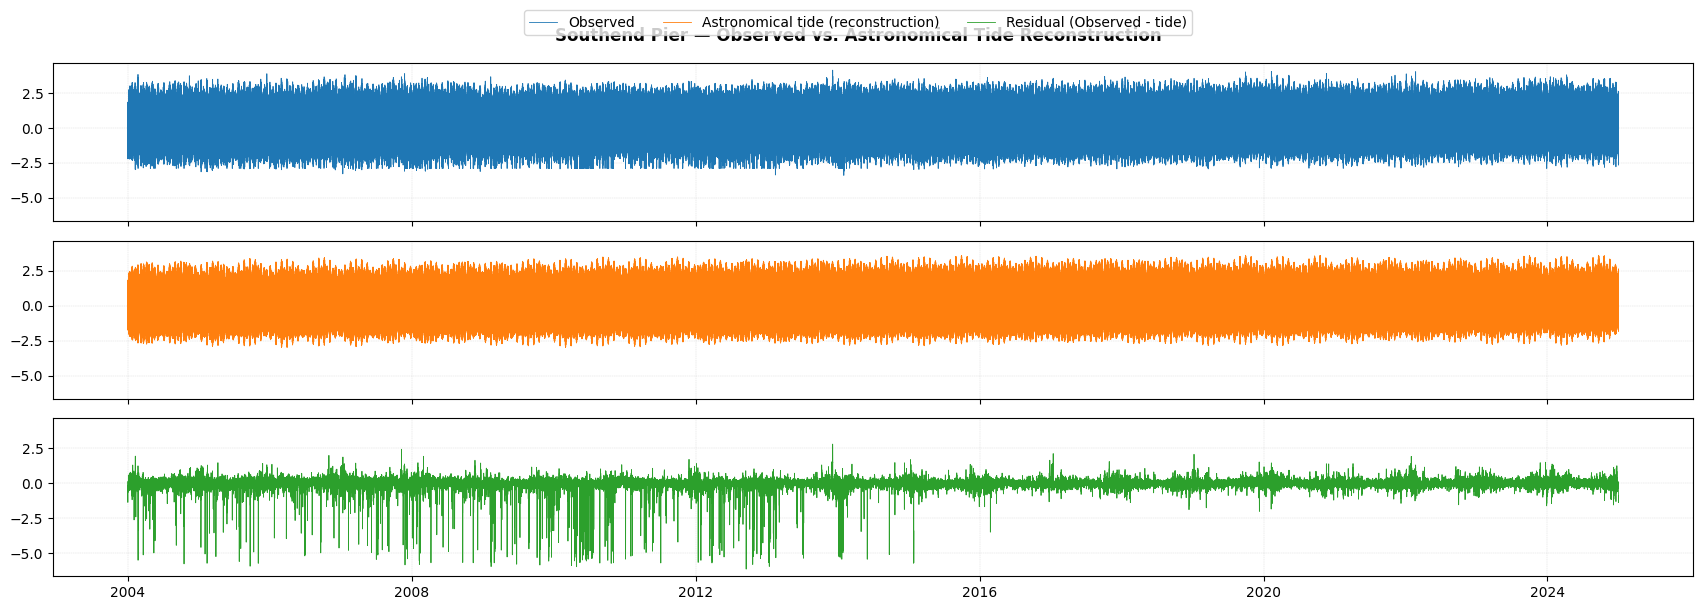

In [8]:
t = obs.index.to_pydatetime()

fig, (ax0, ax1, ax2) = plt.subplots(figsize=(17, 6), nrows=3, sharey=True, sharex=True)

ax0.plot(t, obs['Observed_ODN'], label="Observed", color="C0", linewidth=0.6)
ax1.plot(t, tide.h, label="Astronomical tide (reconstruction)", color="C1", linewidth=0.6)
ax2.plot(t, obs['Observed_ODN'] - tide.h, label="Residual (Observed - tide)", color="C2", linewidth=0.6)

for ax in (ax0, ax1, ax2):
    ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.5)

fig.suptitle("Southend Pier — Observed vs. Astronomical Tide Reconstruction", fontweight="bold")
fig.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.show()

In [9]:
constituents = pd.DataFrame({
    "constituent": coef["name"],
    "amplitude_m": coef["A"],
    "phase_deg": coef["g"],
    "PE_percent": coef["PE"],
}).sort_values("PE_percent", ascending=False).reset_index(drop=True)

print(f"{len(constituents)} constituents resolved "
      f"(conf_int='none' -> no SNR filtering, all included in reconstruction)")
constituents.head(15)

68 constituents resolved (conf_int='none' -> no SNR filtering, all included in reconstruction)


,constituent,amplitude_m,phase_deg,PE_percent
0,M2,2.047810,350.876453,87.142334
1,S2,0.589258,47.900391,7.215403
2,N2,0.344532,326.705775,2.466661
3,K2,0.174000,47.037487,0.629145
4,MU2,0.134672,87.268167,0.376881
5,L2,0.133339,4.819459,0.369459
6,O1,0.129649,187.952153,0.349290
7,K1,0.114724,10.243970,0.273499
8,M4,0.113084,355.009882,0.265736
9,NU2,0.108058,316.950021,0.242642


## Zoomed-in comparison: Observed vs. Astronomical tide

Short windows in January make the tidal cycle (and how well the reconstruction tracks it) easy to see. Comparing 2008 against 2020 also gives a sense of whether the fit holds up similarly across years.

In [10]:
tide_h = pd.Series(tide.h, index=obs.index, name="Astronomical_tide")

COLOR_OBSERVED = "#2a78d6"
COLOR_TIDE = "#eb6834"


def plot_period_comparison(period_label, ranges):
    fig, axes = plt.subplots(figsize=(14, 3.2 * len(ranges)), nrows=len(ranges), ncols=1)

    for ax, (year, start, end) in zip(axes, ranges):
        window = slice(start, end)
        obs_win = obs.loc[window, "Observed_ODN"]
        tide_win = tide_h.loc[window]

        ax.plot(obs_win.index, obs_win, label="Observed", color=COLOR_OBSERVED, linewidth=1.2)
        ax.plot(tide_win.index, tide_win, label="Astronomical tide", color=COLOR_TIDE, linewidth=1.2)

        ax.set_ylabel("m ODN")
        ax.set_title(str(year), loc="left", fontsize=10, color="#52514e")
        ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.5)

    fig.suptitle(f"Southend Pier — Observed vs. Astronomical Tide ({period_label})", fontweight="bold")
    fig.legend(*axes[0].get_legend_handles_labels(), ncol=2, loc="upper center",
               bbox_to_anchor=(0.5, 1.02), frameon=False)
    fig.tight_layout()
    plt.show()

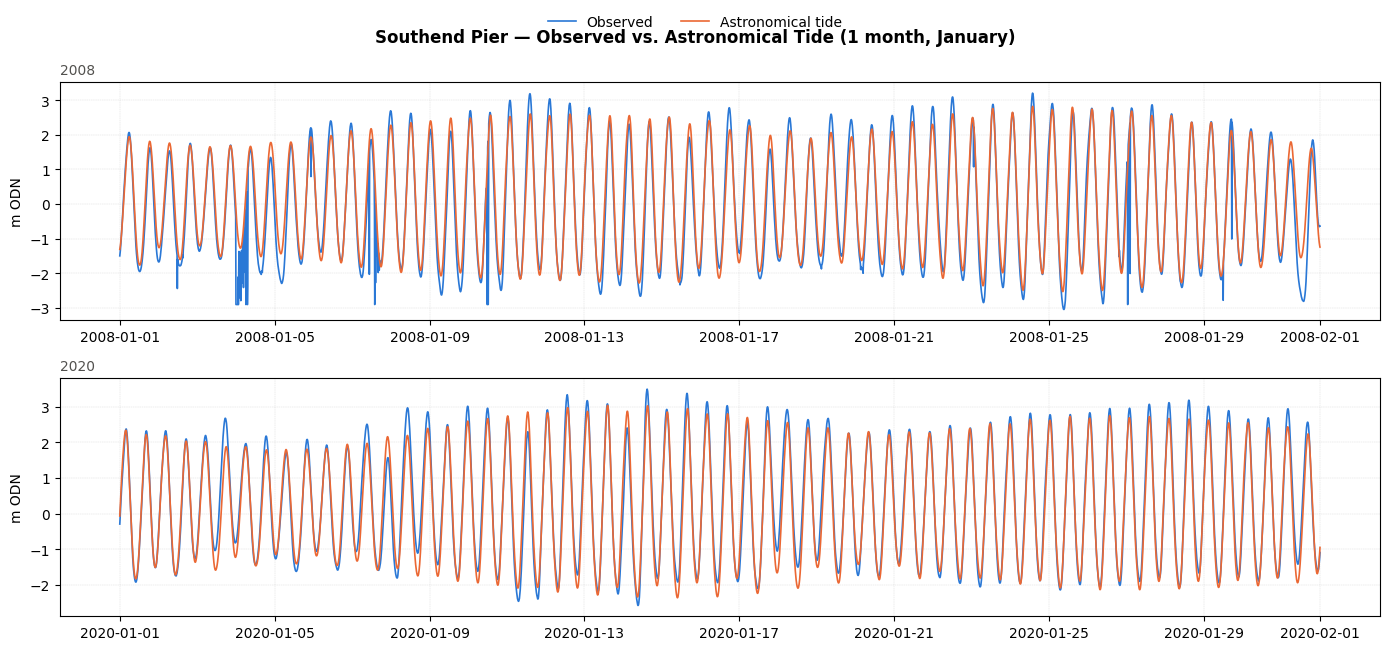

In [11]:
plot_period_comparison(
    "1 month, January",
    ranges=[
        (2008, "2008-01-01", "2008-01-31"),
        (2020, "2020-01-01", "2020-01-31"),
    ],
)

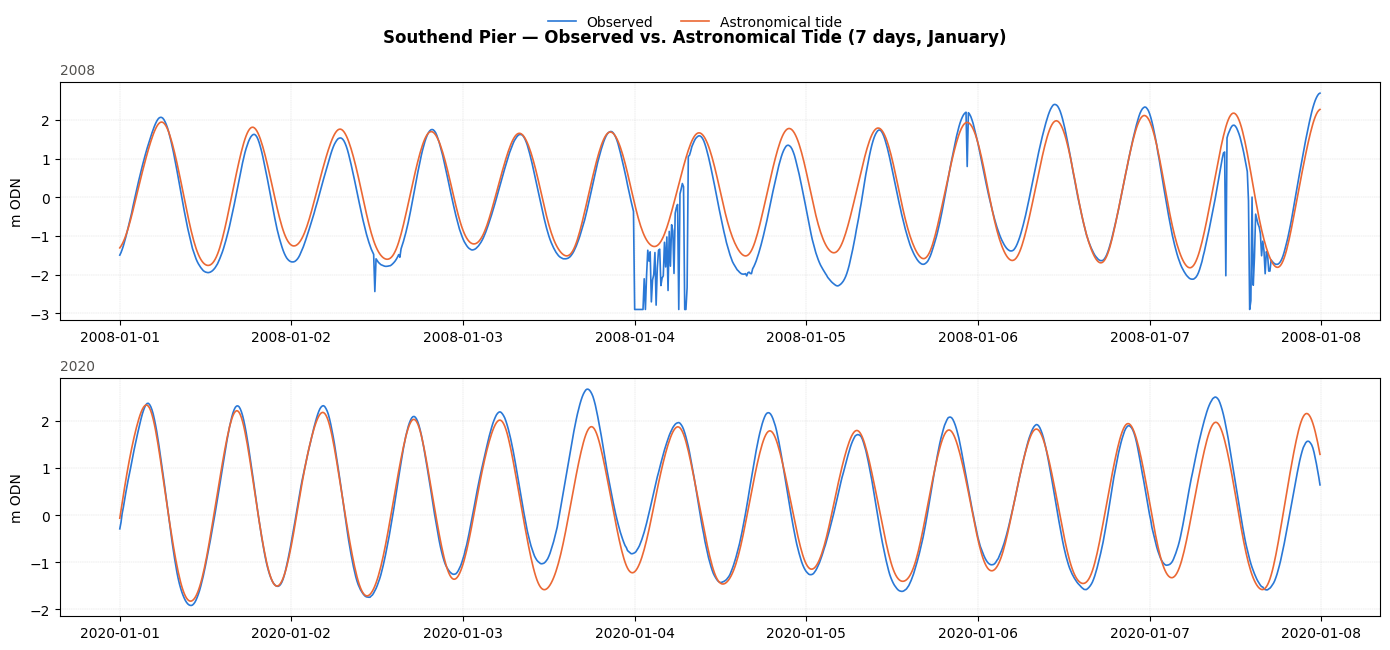

In [12]:
plot_period_comparison(
    "7 days, January",
    ranges=[
        (2008, "2008-01-01", "2008-01-07"),
        (2020, "2020-01-01", "2020-01-07"),
    ],
)

## Sensor Chatter Detection — Stage 1: FLAG

Separate fault from the already-corrected ~-144.5 m spike (tracked via `is_imputed`,
fixed by linear interpolation — not touched here). This targets multi-day episodes of
high-frequency jitter concentrated near low water — sharp back-and-forth movement that
isn't physically plausible surge behaviour, likely a gauge float/mechanism fault —
occurring mostly before ~2016.

Planned as four separate, reviewable stages:

1. **FLAG** (this section) — residual roughness → threshold → episode table
2. **NULL** — set flagged points to NaN on a working copy, tag `is_chatter_flagged`
3. **REFIT** — re-run UTide excluding the nulled points, compare constituents to the original fit
4. **PATCH** — fill flagged points from the refit reconstruction, tag `imputation_method`

Stopping after Stage 1 to confirm `ROUGHNESS_THRESHOLD` against the data before nulling or refitting anything.

In [13]:
import os

CHATTER_OUTPUT_DIR = os.path.join("..", "outputs", "temporal_eda")
os.makedirs(CHATTER_OUTPUT_DIR, exist_ok=True)

# Residual against the original UTide fit computed above (coef / tide_h).
residual = (obs["Observed_ODN"] - tide_h).rename("residual")

ROUGHNESS_WINDOW_SAMPLES = 9  # ~90 min at 10-min resolution; within the 6-12 sample (1-2h) range

roughness = residual.rolling(
    window=ROUGHNESS_WINDOW_SAMPLES,
    center=True,
    min_periods=ROUGHNESS_WINDOW_SAMPLES // 2 + 1,
).std().rename("roughness")

print(f"residual  : n={residual.notna().sum():,}  mean={residual.mean():.4f} m  std={residual.std():.4f} m")
print(f"roughness : {ROUGHNESS_WINDOW_SAMPLES}-sample ({ROUGHNESS_WINDOW_SAMPLES*10} min) "
      f"centered rolling std of residual, n={roughness.notna().sum():,}")

residual  : n=1,103,956  mean=0.0000 m  std=0.3062 m
roughness : 9-sample (90 min) centered rolling std of residual, n=1,103,956


In [14]:
CUTOFF_2016 = pd.Timestamp("2016-01-01")
pre2016 = obs.index < CUTOFF_2016

roughness_stats = roughness.describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.995, 0.999, 0.9999])
print("Roughness — full record:")
print(roughness_stats)

# Chatter is reported mostly pre-2016, so the post-2016 distribution gives a rough
# read on what "clean" roughness looks like (not a guarantee — some episodes may
# fall after 2016 too, per the task description).
compare = pd.DataFrame({
    "pre_2016":  roughness[pre2016].describe(percentiles=[0.9, 0.99, 0.999]),
    "post_2016": roughness[~pre2016].describe(percentiles=[0.9, 0.99, 0.999]),
})
print("\nRoughness — pre-2016 vs post-2016:")
print(compare)

Roughness — full record:
count     1.103956e+06
mean      4.586630e-02
std       1.059315e-01
min       5.814855e-04
50%       3.127333e-02
90%       7.729220e-02
95%       9.741679e-02
99%       2.061944e-01
99.5%     5.182620e-01
99.9%     1.894436e+00
99.99%    2.685613e+00
max       3.121846e+00
Name: roughness, dtype: float64

Roughness — pre-2016 vs post-2016:
            pre_2016      post_2016
count  630579.000000  473377.000000
mean        0.052561       0.036948
std         0.137653       0.028094
min         0.000581       0.000675
50%         0.032393       0.029887
90%         0.081100       0.072440
99%         0.446215       0.130948
99.9%       2.194523       0.203673
max         3.121846       1.180473


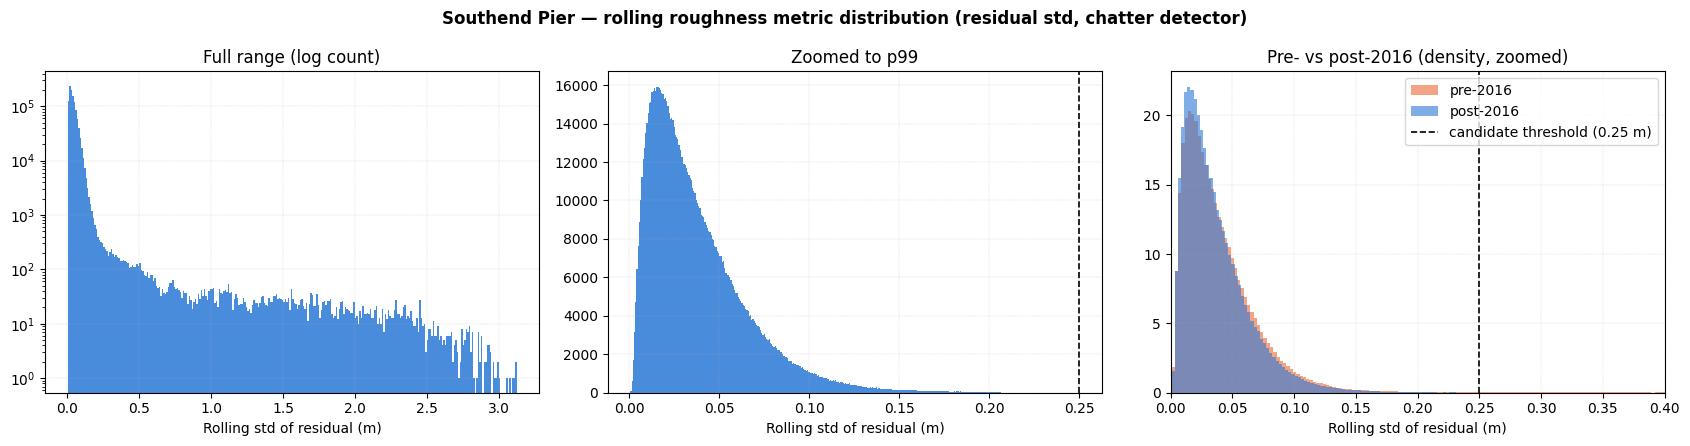

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].hist(roughness.dropna(), bins=300, color="#2a78d6", alpha=0.85)
axes[0].set_yscale("log")
axes[0].set_title("Full range (log count)")
axes[0].set_xlabel("Rolling std of residual (m)")

# Zoom to p99 (not p99.9) -- the decision boundary sits well inside this range,
# whereas p99.9 (~1.9 m) squashes everything near zero into a spike.
p99 = roughness.quantile(0.99)
axes[1].hist(roughness[roughness <= p99].dropna(), bins=300, color="#2a78d6", alpha=0.85)
axes[1].set_title("Zoomed to p99")
axes[1].set_xlabel("Rolling std of residual (m)")

zoom_max = 0.4
axes[2].hist(roughness[pre2016 & (roughness <= zoom_max)].dropna(), bins=150, alpha=0.6,
             label="pre-2016", color="#eb6834", density=True)
axes[2].hist(roughness[~pre2016 & (roughness <= zoom_max)].dropna(), bins=150, alpha=0.6,
             label="post-2016", color="#2a78d6", density=True)
axes[2].set_xlim(0, zoom_max)
axes[2].set_title("Pre- vs post-2016 (density, zoomed)")
axes[2].set_xlabel("Rolling std of residual (m)")

# Candidate threshold, set explicitly (not read from a variable) since this cell
# runs before ROUGHNESS_THRESHOLD is defined below -- keep the two in sync.
CANDIDATE_THRESHOLD_FOR_PLOT = 0.25
for ax in (axes[1], axes[2]):
    ax.axvline(CANDIDATE_THRESHOLD_FOR_PLOT, color="black", linestyle="--", linewidth=1.2,
               label=f"candidate threshold ({CANDIDATE_THRESHOLD_FOR_PLOT} m)")
axes[2].legend()

for ax in axes:
    ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.5)

fig.suptitle("Southend Pier — rolling roughness metric distribution (residual std, chatter detector)",
             fontweight="bold")
plt.tight_layout()
plt.show()

In [16]:
def group_into_episodes(flag_series, max_gap):
    """Group flagged timestamps into episodes; gaps <= max_gap still count as one episode."""
    flagged_times = flag_series[flag_series].index
    if len(flagged_times) == 0:
        return pd.DataFrame(columns=["start", "end", "duration_hours", "n_points"])
    times = flagged_times.to_series()
    gap = times.diff()
    episode_id = (gap.isna() | (gap > max_gap)).cumsum()
    ep = times.groupby(episode_id.values).agg(start="min", end="max", n_points="count")
    ep["duration_hours"] = (ep["end"] - ep["start"]).dt.total_seconds() / 3600
    return ep.reset_index(drop=True)[["start", "end", "duration_hours", "n_points"]]


MAX_EPISODE_GAP = pd.Timedelta(hours=1)

# Threshold sweep — helps pick ROUGHNESS_THRESHOLD below from evidence rather than
# a blind guess. Real fault chatter should show up as a *small* number of
# *multi-day* episodes concentrated pre-2016 -- not thousands of few-point blips
# spread across every year (that pattern is routine slack-water residual noise).
candidate_thresholds = [0.08, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.75, 1.00, 1.50]

sweep_rows = []
for thr in candidate_thresholds:
    flag = (roughness > thr) & (~obs["is_imputed"])
    ep = group_into_episodes(flag, MAX_EPISODE_GAP)
    long_ep = ep[ep["duration_hours"] >= 24]  # "multi-day"-scale episodes
    sweep_rows.append({
        "threshold_m":          thr,
        "n_points_flagged":     int(flag.sum()),
        "pct_of_record":        round(100 * flag.mean(), 4),
        "n_episodes":           len(ep),
        "n_episodes_ge_24h":    len(long_ep),
        "median_duration_hr":   round(ep["duration_hours"].median(), 2) if len(ep) else 0,
        "max_duration_hr":      round(ep["duration_hours"].max(), 2) if len(ep) else 0,
        "pct_episodes_pre2016": round(100 * (ep["start"] < CUTOFF_2016).mean(), 1) if len(ep) else float("nan"),
    })

sweep = pd.DataFrame(sweep_rows)
sweep

C:\Users\alfat\AppData\Local\Temp\ipykernel_15324\3968050778.py:14: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  MAX_EPISODE_GAP = pd.Timedelta(hours=1)


,threshold_m,n_points_flagged,pct_of_record,n_episodes,n_episodes_ge_24h,median_duration_hr,max_duration_hr,pct_episodes_pre2016
0,0.08,100107,9.0680,12680,1,1.00,32.17,62.2
1,0.10,50909,4.6115,6533,0,1.00,23.83,65.1
2,0.15,17074,1.5466,1696,0,1.33,19.33,77.0
3,0.20,11379,1.0307,923,0,1.33,18.00,90.5
4,0.25,9586,0.8683,719,0,1.33,17.83,96.5
5,0.30,8541,0.7737,638,0,1.33,17.83,98.4
6,0.40,6883,0.6235,532,0,1.33,12.67,99.4
7,0.50,5724,0.5185,463,0,1.33,10.17,99.6
8,0.75,4198,0.3803,354,0,1.33,7.33,99.7
9,1.00,3380,0.3062,302,0,1.33,6.50,99.7


In [17]:
# ── Adjustable threshold — inspect the plot, percentiles, and sweep table above ──
# 0.25 m sits just above the post-2016 "clean" ceiling (post-2016 p99.9 = 0.204 m,
# max = 1.18 m) with some margin, while the sweep table shows it captures the bulk
# of the pre-2016 tail (719 episodes, 96.5% starting pre-2016). Adjust and re-run
# this cell onward if the episode table below doesn't look right.
ROUGHNESS_THRESHOLD = 0.25  # m

is_flagged = (roughness > ROUGHNESS_THRESHOLD) & (~obs["is_imputed"])
# is_imputed rows are excluded from flagging — that correction already lives
# elsewhere and must not be touched by this pass.

print(f"ROUGHNESS_THRESHOLD = {ROUGHNESS_THRESHOLD} m")
print(f"Flagged points: {int(is_flagged.sum()):,} ({100 * is_flagged.mean():.4f}% of record)")

episodes = group_into_episodes(is_flagged, MAX_EPISODE_GAP)
episodes.insert(0, "episode_id", range(1, len(episodes) + 1))
episodes

ROUGHNESS_THRESHOLD = 0.25 m
Flagged points: 9,586 (0.8683% of record)


,episode_id,start,end,duration_hours,n_points
0,1,2004-01-20 09:40:00,2004-01-20 11:00:00,1.333333,9
1,2,2004-01-23 08:30:00,2004-01-23 10:30:00,2.000000,13
2,3,2004-01-26 11:20:00,2004-01-26 13:00:00,1.666667,11
3,4,2004-02-02 10:00:00,2004-02-02 12:20:00,2.333333,15
4,5,2004-02-04 22:30:00,2004-02-04 23:50:00,1.333333,9
...,...,...,...,...,...
714,715,2022-08-12 10:00:00,2022-08-12 10:10:00,0.166667,2
715,716,2022-10-01 01:00:00,2022-10-01 02:10:00,1.166667,8
716,717,2024-02-01 02:10:00,2024-02-01 02:50:00,0.666667,5
717,718,2024-12-05 12:30:00,2024-12-05 13:20:00,0.833333,6


In [18]:
record_hours = (obs.index.max() - obs.index.min()).total_seconds() / 3600
pre2016_hours = pre2016.sum() * 10 / 60  # 10-min samples -> hours

total_flagged_hours = episodes["duration_hours"].sum() if len(episodes) else 0.0
pre2016_flagged_hours = (
    episodes.loc[episodes["start"] < CUTOFF_2016, "duration_hours"].sum() if len(episodes) else 0.0
)

totals = {
    "n_episodes":            int(len(episodes)),
    "total_points_flagged":  int(episodes["n_points"].sum()) if len(episodes) else 0,
    "total_hours_flagged":   round(float(total_flagged_hours), 2),
    "pct_of_full_record":    round(100 * total_flagged_hours / record_hours, 4),
    "pct_of_pre2016_record": round(100 * pre2016_flagged_hours / pre2016_hours, 4) if pre2016_hours else float("nan"),
}

print("Episode totals:")
for k, v in totals.items():
    print(f"  {k}: {v}")

episodes.to_csv(os.path.join(CHATTER_OUTPUT_DIR, "southend_chatter_episodes.csv"), index=False)
pd.DataFrame([totals]).to_csv(os.path.join(CHATTER_OUTPUT_DIR, "southend_chatter_summary.csv"), index=False)
print(f"\nSaved episode table -> {CHATTER_OUTPUT_DIR}/southend_chatter_episodes.csv")
print(f"Saved totals        -> {CHATTER_OUTPUT_DIR}/southend_chatter_summary.csv")

Episode totals:
  n_episodes: 719
  total_points_flagged: 9586
  total_hours_flagged: 1511.83
  pct_of_full_record: 0.8212
  pct_of_pre2016_record: 1.4177

Saved episode table -> ..\outputs\temporal_eda/southend_chatter_episodes.csv
Saved totals        -> ..\outputs\temporal_eda/southend_chatter_summary.csv


### Diagnostic: do the episodes above cluster into multi-day "outbreaks"?

Near-low-water chatter recurs roughly every ~12.4 h (once per semidiurnal cycle), which
is longer than the 1-hour merge gap specified for `episodes` above — so a real multi-day
fault period shows up as *many short episodes that are tightly clustered in calendar
time*, not one long row. This cell re-clusters `episodes` across a much wider gap purely
to sanity-check that against "several multi-day episodes" — it does **not** change
`episodes`, `is_flagged`, or anything used downstream.

In [19]:
OUTBREAK_MERGE_GAP = pd.Timedelta(days=3)  # diagnostic-only, wider than MAX_EPISODE_GAP

ep_sorted = episodes.sort_values("start").reset_index(drop=True)
gap_to_next = ep_sorted["start"].shift(-1) - ep_sorted["end"]
outbreak_id = (gap_to_next.shift(1) > OUTBREAK_MERGE_GAP).cumsum()
outbreaks = (ep_sorted.groupby(outbreak_id)
             .agg(start=("start", "min"), end=("end", "max"),
                  n_episodes=("start", "count"), n_points=("n_points", "sum")))
outbreaks["span_days"] = (outbreaks["end"] - outbreaks["start"]).dt.total_seconds() / 86400
outbreaks = outbreaks.sort_values("start").reset_index(drop=True)

print(f"{len(episodes)} raw (1h-gap) episodes -> {len(outbreaks)} outbreak clusters "
      f"under a {OUTBREAK_MERGE_GAP} merge gap")
print(f"Outbreak clusters spanning >= 1 day: {(outbreaks['span_days'] >= 1).sum()}")
print(f"Outbreak clusters starting pre-2016: {(outbreaks['start'] < CUTOFF_2016).sum()} / {len(outbreaks)}")

outbreaks.sort_values("n_points", ascending=False).head(20)

719 raw (1h-gap) episodes -> 314 outbreak clusters under a 3 days 00:00:00 merge gap
Outbreak clusters spanning >= 1 day: 110
Outbreak clusters starting pre-2016: 294 / 314


C:\Users\alfat\AppData\Local\Temp\ipykernel_15324\2284054843.py:1: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  OUTBREAK_MERGE_GAP = pd.Timedelta(days=3)  # diagnostic-only, wider than MAX_EPISODE_GAP


,start,end,n_episodes,n_points,span_days
188,2010-04-15 01:50:00,2010-04-28 13:30:00,19,498,13.486111
203,2010-10-23 11:30:00,2010-11-04 20:10:00,22,386,12.361111
192,2010-05-28 11:00:00,2010-06-06 04:00:00,12,286,8.708333
194,2010-06-21 23:30:00,2010-07-05 11:00:00,12,213,13.479167
69,2006-06-29 03:10:00,2006-07-01 16:20:00,7,197,2.548611
181,2010-01-17 00:30:00,2010-02-02 16:00:00,16,192,16.645833
167,2009-08-22 22:30:00,2009-08-28 10:10:00,9,191,5.486111
249,2012-10-20 08:50:00,2012-10-29 22:20:00,11,173,9.562500
176,2009-12-03 07:00:00,2009-12-10 03:30:00,8,168,6.854167
195,2010-07-08 15:00:00,2010-07-16 00:00:00,9,156,7.375000


## Sensor Chatter Detection — Stage 2: NULL

`ROUGHNESS_THRESHOLD = 0.25 m` and the 1-hour episode gap confirmed above. Working on
a copy (`obs_nulled`) — the original `obs` stays untouched so the original UTide fit
(`coef`, `tide_h`) remains available for the before/after comparison in Stage 3.

In [20]:
obs_nulled = obs.copy()

obs_nulled["is_chatter_flagged"] = is_flagged
assert not (obs_nulled["is_chatter_flagged"] & obs_nulled["is_imputed"]).any(), (
    "chatter flags must never overlap the existing is_imputed correction"
)

n_odn_nan_before = obs_nulled["Observed_ODN"].isna().sum()
n_obs_nan_before = obs_nulled["Observed"].isna().sum()

obs_nulled.loc[obs_nulled["is_chatter_flagged"], ["Observed", "Observed_ODN"]] = np.nan

n_odn_nan_after = obs_nulled["Observed_ODN"].isna().sum()
n_obs_nan_after = obs_nulled["Observed"].isna().sum()

print(f"is_chatter_flagged : {int(obs_nulled['is_chatter_flagged'].sum()):,} rows")
print(f"Observed   NaNs     : {n_obs_nan_before:,} -> {n_obs_nan_after:,}  (+{n_obs_nan_after - n_obs_nan_before:,})")
print(f"Observed_ODN NaNs   : {n_odn_nan_before:,} -> {n_odn_nan_after:,}  (+{n_odn_nan_after - n_odn_nan_before:,})")

# is_imputed row must be completely untouched by this stage
_imp_mask = obs["is_imputed"]
unchanged = obs.loc[_imp_mask, ["Observed", "Observed_ODN"]].equals(
    obs_nulled.loc[_imp_mask, ["Observed", "Observed_ODN"]]
)
print(f"is_imputed row(s) unchanged: {unchanged}")

is_chatter_flagged : 9,586 rows
Observed   NaNs     : 0 -> 9,586  (+9,586)
Observed_ODN NaNs   : 0 -> 9,586  (+9,586)
is_imputed row(s) unchanged: True


## Sensor Chatter Detection — Stage 3: REFIT

`utide.solve` masks invalid (`NaN`) observations with `np.ma.masked_invalid` and
`.compress()`es them out before building the least-squares system (see
`utide/_solve.py::_slvinit`) — NaNs are dropped from the fit, not coerced to zero.
The cell below refits on `obs_nulled` and confirms the dropped-row count matches
`is_chatter_flagged` exactly.

In [21]:
n_valid_input = obs_nulled["Observed_ODN"].notna().sum()
n_total = len(obs_nulled)

coef_refit = utide.solve(
    obs_nulled.index, obs_nulled["Observed_ODN"], lat=site_lat, method="ols", conf_int="none"
)

# coef["weights"] has one entry per observation utide.solve actually used to
# build the least-squares system -- confirms NaNs were dropped, not zero-filled
# (a zero-fill would leave weights at the original 1,103,956-row length).
n_used_by_solve = len(coef_refit["weights"])
print(f"obs_nulled: {n_total:,} rows total, {n_valid_input:,} valid (non-NaN) Observed_ODN")
print(f"utide.solve internally used: {n_used_by_solve:,} rows "
      f"(matches valid count: {n_used_by_solve == n_valid_input})")

tide_refit = utide.reconstruct(obs_nulled.index, coef_refit, verbose=False)
tide_h_refit = pd.Series(tide_refit.h, index=obs_nulled.index, name="Astronomical_tide_refit")

print(f"\n{len(coef_refit['name'])} constituents resolved in refit "
      f"(original fit resolved {len(coef['name'])})")

solve: matrix prep ... 

solution ... 

done.
obs_nulled: 1,103,956 rows total, 1,094,370 valid (non-NaN) Observed_ODN
utide.solve internally used: 1,094,370 rows (matches valid count: True)



68 constituents resolved in refit (original fit resolved 68)


In [22]:
constituents_refit = pd.DataFrame({
    "constituent": coef_refit["name"],
    "amplitude_m_refit": coef_refit["A"],
    "phase_deg_refit": coef_refit["g"],
    "PE_percent_refit": coef_refit["PE"],
})

constituents_original = constituents.rename(columns={
    "amplitude_m": "amplitude_m_original",
    "phase_deg": "phase_deg_original",
    "PE_percent": "PE_percent_original",
})

# outer join: a constituent resolved in one fit but not the other still shows up
# (with NaN on the missing side) rather than being silently dropped from view.
constituent_comparison = constituents_original.merge(
    constituents_refit, on="constituent", how="outer"
)
constituent_comparison["delta_amplitude_m"] = (
    constituent_comparison["amplitude_m_refit"] - constituent_comparison["amplitude_m_original"]
)
constituent_comparison["delta_phase_deg"] = (
    constituent_comparison["phase_deg_refit"] - constituent_comparison["phase_deg_original"]
)
constituent_comparison["delta_PE_percent"] = (
    constituent_comparison["PE_percent_refit"] - constituent_comparison["PE_percent_original"]
)
constituent_comparison = constituent_comparison.sort_values(
    "PE_percent_original", ascending=False, na_position="last"
).reset_index(drop=True)

pd.set_option("display.float_format", lambda x: f"{x:.6f}")
print(f"Constituents — original: {len(constituents_original)}, refit: {len(constituents_refit)}")
print(f"Largest |delta_amplitude_m|: {constituent_comparison['delta_amplitude_m'].abs().max():.6f} m")
print(f"Largest |delta_phase_deg|:   {constituent_comparison['delta_phase_deg'].abs().max():.6f} deg")

CHATTER_OUTPUT_DIR = os.path.join("..", "outputs", "temporal_eda")
constituent_comparison.to_csv(
    os.path.join(CHATTER_OUTPUT_DIR, "southend_chatter_constituent_comparison.csv"), index=False
)
print(f"\nSaved -> {CHATTER_OUTPUT_DIR}/southend_chatter_constituent_comparison.csv")

constituent_comparison.head(15)

Constituents — original: 68, refit: 68
Largest |delta_amplitude_m|: 0.007980 m
Largest |delta_phase_deg|:   37.092461 deg

Saved -> ..\outputs\temporal_eda/southend_chatter_constituent_comparison.csv


,constituent,amplitude_m_original,phase_deg_original,PE_percent_original,amplitude_m_refit,phase_deg_refit,PE_percent_refit,delta_amplitude_m,delta_phase_deg,delta_PE_percent
0,M2,2.047810,350.876453,87.142334,2.055791,350.894701,87.157767,0.007980,0.018249,0.015433
1,S2,0.589258,47.900391,7.215403,0.590952,48.005208,7.201991,0.001694,0.104817,-0.013412
2,N2,0.344532,326.705775,2.466661,0.347305,326.741199,2.487542,0.002773,0.035424,0.020881
3,K2,0.174000,47.037487,0.629145,0.174321,46.964462,0.626681,0.000320,-0.073026,-0.002464
4,MU2,0.134672,87.268167,0.376881,0.134333,88.147823,0.372144,-0.000339,0.879656,-0.004737
5,L2,0.133339,4.819459,0.369459,0.133700,5.067664,0.368648,0.000361,0.248205,-0.000811
6,O1,0.129649,187.952153,0.349290,0.129918,188.078334,0.348089,0.000270,0.126181,-0.001201
7,K1,0.114724,10.243970,0.273499,0.114396,10.171854,0.269880,-0.000328,-0.072116,-0.003620
8,M4,0.113084,355.009882,0.265736,0.113850,355.471207,0.267309,0.000766,0.461324,0.001573
9,NU2,0.108058,316.950021,0.242642,0.106577,317.102524,0.234248,-0.001481,0.152504,-0.008395


In [23]:
# Overall goodness-of-fit, evaluated only on the "clean" points (excludes both
# is_chatter_flagged and is_imputed) -- comparing on fault-contaminated points
# would just measure how large the fault was, not how well either fit tracks
# genuine tidal behaviour.
clean_mask = (~is_flagged) & (~obs["is_imputed"])

resid_original_clean = (obs["Observed_ODN"] - tide_h)[clean_mask]
resid_refit_clean = (obs["Observed_ODN"] - tide_h_refit)[clean_mask]

print("Residual std, evaluated on clean (non-flagged, non-imputed) points only:")
print(f"  original fit : {resid_original_clean.std():.4f} m")
print(f"  refit        : {resid_refit_clean.std():.4f} m")
print(f"  change       : {resid_refit_clean.std() - resid_original_clean.std():+.4f} m")

print(f"\nTotal PE (percent variance) — original: {constituents_original['PE_percent_original'].sum():.4f}%, "
      f"refit: {constituents_refit['PE_percent_refit'].sum():.4f}%")

Residual std, evaluated on clean (non-flagged, non-imputed) points only:
  original fit : 0.2508 m
  refit        : 0.2505 m
  change       : -0.0002 m

Total PE (percent variance) — original: 100.0000%, refit: 100.0000%


## Sensor Chatter Detection — Stage 4: PATCH

Fill only the flagged timestamps from the refit reconstruction (`tide_h_refit`); everything
else in `obs_nulled` — including any other, unrelated missing data — is left as-is. Tags the
patched rows `imputation_method = "utide_reconstruction"`, distinct from the existing
`"linear"` spike fix, so the two corrections stay traceable separately.

In [24]:
GAUGE_METADATA = pd.read_csv("../3_Cleaned/00_gauge_metadata.csv").set_index("idSite")
odn_offset = GAUGE_METADATA.loc["10_SOUTHEND", "ChartDatum_m_below_ODN"]  # Observed_ODN = Observed - offset
print(f"Southend Pier ODN offset: {odn_offset} m below ODN")

obs_patched = obs_nulled.copy()

# imputation_method: preserve the existing "linear" tag from Stage-0 spike fix,
# add "utide_reconstruction" for this pass's patched rows. Never both at once
# (already asserted in Stage 2 that the flag sets don't overlap).
obs_patched["imputation_method"] = "none"
obs_patched.loc[obs_patched["is_imputed"], "imputation_method"] = "linear"
obs_patched.loc[obs_patched["is_chatter_flagged"], "imputation_method"] = "utide_reconstruction"

patch_mask = obs_patched["is_chatter_flagged"]
n_before_patch = obs_patched.loc[patch_mask, "Observed_ODN"].isna().sum()

obs_patched.loc[patch_mask, "Observed_ODN"] = tide_h_refit.loc[patch_mask]
obs_patched.loc[patch_mask, "Observed"] = tide_h_refit.loc[patch_mask] + odn_offset

n_after_patch = obs_patched.loc[patch_mask, "Observed_ODN"].isna().sum()

print(f"\nPatched rows        : {int(patch_mask.sum()):,}")
print(f"NaN before patch    : {n_before_patch:,}")
print(f"NaN after patch     : {n_after_patch:,}")
print(f"\nimputation_method value counts:")
print(obs_patched["imputation_method"].value_counts())

# Any other pre-existing missing data (not chatter, not the spike) must be left alone.
other_nan_mask = obs_patched["Observed_ODN"].isna() & ~patch_mask
print(f"\nOther untouched NaNs remaining (unrelated missing data, left as-is): {int(other_nan_mask.sum()):,}")

Southend Pier ODN offset: 2.9 m below ODN

Patched rows        : 9,586
NaN before patch    : 9,586
NaN after patch     : 0

imputation_method value counts:
imputation_method
none                    1094369
utide_reconstruction       9586
linear                        1
Name: count, dtype: int64

Other untouched NaNs remaining (unrelated missing data, left as-is): 0


In [25]:
print("=" * 78)
print("REMINDER: exclude patched points from train/val/test splits")
print("=" * 78)
print(
    "Rows with imputation_method == 'utide_reconstruction' (and 'linear') are\n"
    "*not* real surge observations -- they are UTide's own tidal reconstruction\n"
    "written back into the record. Any future split used to score a model's skill\n"
    "against UTide must exclude these rows from evaluation (and arguably from\n"
    "training too), or the comparison will be circular / artificially inflated."
)

# Saved to a review file, not overwriting the canonical 3_Cleaned/10_SOUTHEND.csv --
# that's a shared file other notebooks (gauge_ts.ipynb, EDA) read from, so promoting
# this output should be a deliberate, separate step once you've reviewed it.
REVIEW_PATH = "../3_Cleaned/10_SOUTHEND_chatter_patched.csv"
obs_patched.to_csv(REVIEW_PATH)
print(f"\nSaved patched series for review -> {REVIEW_PATH}")
print("(3_Cleaned/10_SOUTHEND.csv is untouched -- let me know if you want this promoted.)")

REMINDER: exclude patched points from train/val/test splits
Rows with imputation_method == 'utide_reconstruction' (and 'linear') are
*not* real surge observations -- they are UTide's own tidal reconstruction
written back into the record. Any future split used to score a model's skill
against UTide must exclude these rows from evaluation (and arguably from
training too), or the comparison will be circular / artificially inflated.



Saved patched series for review -> ../3_Cleaned/10_SOUTHEND_chatter_patched.csv
(3_Cleaned/10_SOUTHEND.csv is untouched -- let me know if you want this promoted.)


## QA — Before/After Overlay Plots

One overlay per episode (observed original vs. patched, with the refit tide reconstruction
for reference), saved to disk for browsing since 719 inline plots would be unusable. A
sample of the most heavily-flagged episodes is shown inline below as a spot-check.

In [26]:
QA_DIR = os.path.join(CHATTER_OUTPUT_DIR, "chatter_episode_qa")
os.makedirs(QA_DIR, exist_ok=True)

PAD = pd.Timedelta(hours=2)


def plot_episode(row):
    start, end = row["start"], row["end"]
    window = slice(start - PAD, end + PAD)

    obs_win = obs.loc[window, "Observed_ODN"]
    patched_win = obs_patched.loc[window, "Observed_ODN"]
    tide_win = tide_h_refit.loc[window]

    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.plot(obs_win.index, obs_win, color="#eb6834", linewidth=1.1, label="Observed (original)")
    ax.plot(patched_win.index, patched_win, color="#2a9d47", linewidth=1.3, linestyle="--", label="Patched")
    ax.plot(tide_win.index, tide_win, color="#2a78d6", linewidth=0.9, alpha=0.8, label="UTide reconstruction (refit)")
    ax.axvspan(start, end, color="grey", alpha=0.15, label="Flagged episode")
    ax.set_title(
        f"Episode {int(row['episode_id'])} — {start:%Y-%m-%d %H:%M} to {end:%Y-%m-%d %H:%M} "
        f"({row['duration_hours']:.2f} h, {int(row['n_points'])} pts)",
        fontsize=9,
    )
    ax.set_ylabel("m ODN", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.5)
    ax.legend(fontsize=7, loc="upper right")
    fig.tight_layout()
    return fig


print(f"Generating {len(episodes)} before/after QA plots -> {QA_DIR} ...")
for _, row in episodes.iterrows():
    fig = plot_episode(row)
    fname = f"episode_{int(row['episode_id']):04d}_{row['start']:%Y%m%d_%H%M}.png"
    fig.savefig(os.path.join(QA_DIR, fname), dpi=110, bbox_inches="tight")
    plt.close(fig)
print(f"Done — {len(episodes)} PNGs saved.")

Generating 719 before/after QA plots -> ..\outputs\temporal_eda\chatter_episode_qa ...


C:\Users\alfat\AppData\Local\Temp\ipykernel_15324\1145203837.py:4: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  PAD = pd.Timedelta(hours=2)


Done — 719 PNGs saved.


Inline preview — the 6 episodes with the most flagged points:


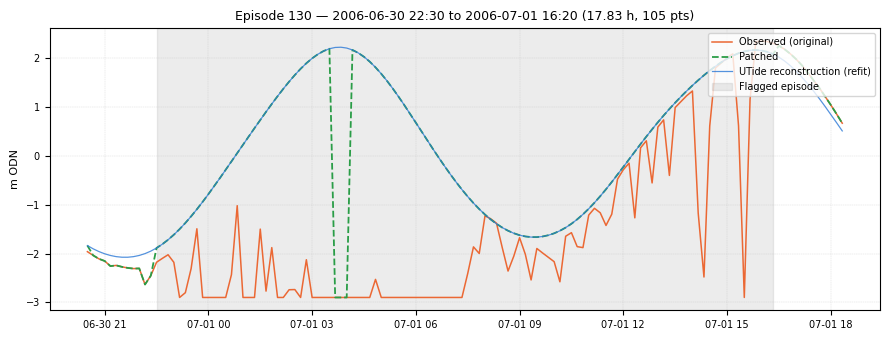

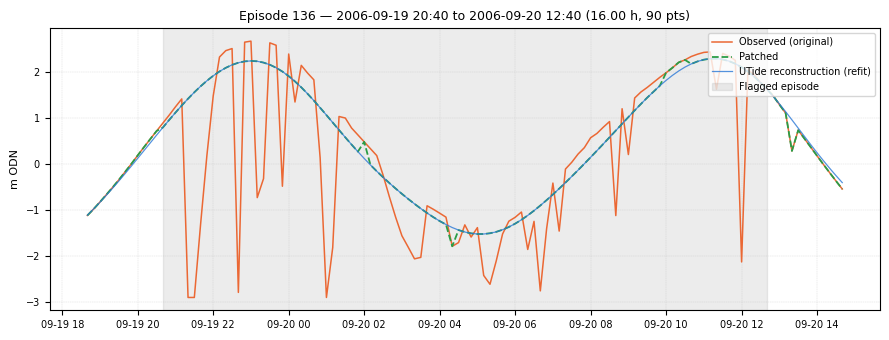

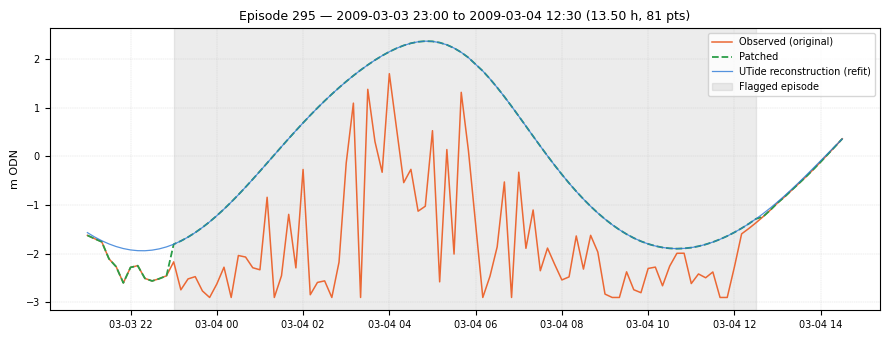

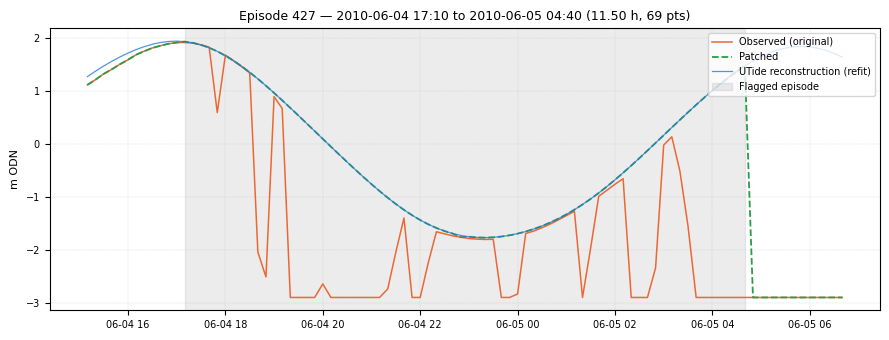

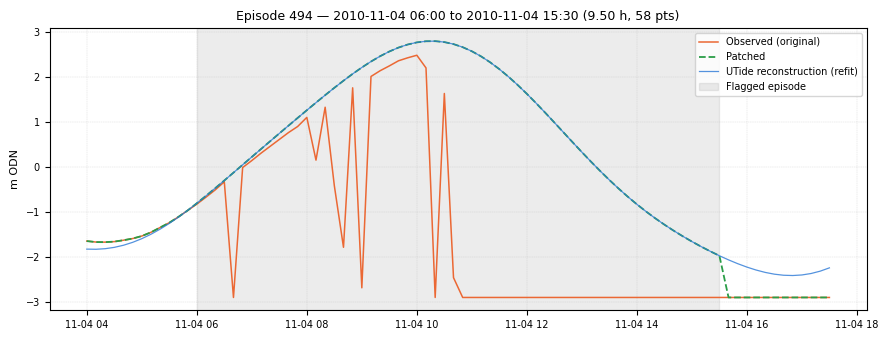

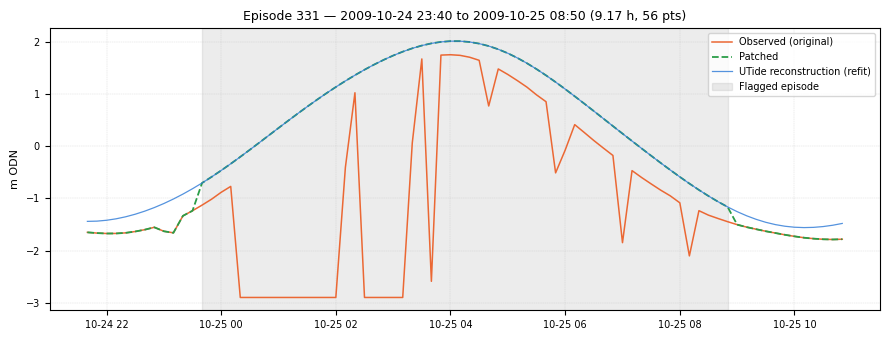

In [27]:
sample_ids = episodes.nlargest(6, "n_points")["episode_id"].tolist()
print(f"Inline preview — the {len(sample_ids)} episodes with the most flagged points:")
for eid in sample_ids:
    row = episodes.loc[episodes["episode_id"] == eid].iloc[0]
    plot_episode(row)
    plt.show()

## Updated Full-Record Overview (post chatter-patch)

Same three-panel layout as the original Observed / Reconstructed tide / Residual plot at
the top of this notebook, rebuilt on `obs_patched` + `tide_h_refit` to confirm the chatter
is gone across the whole record.

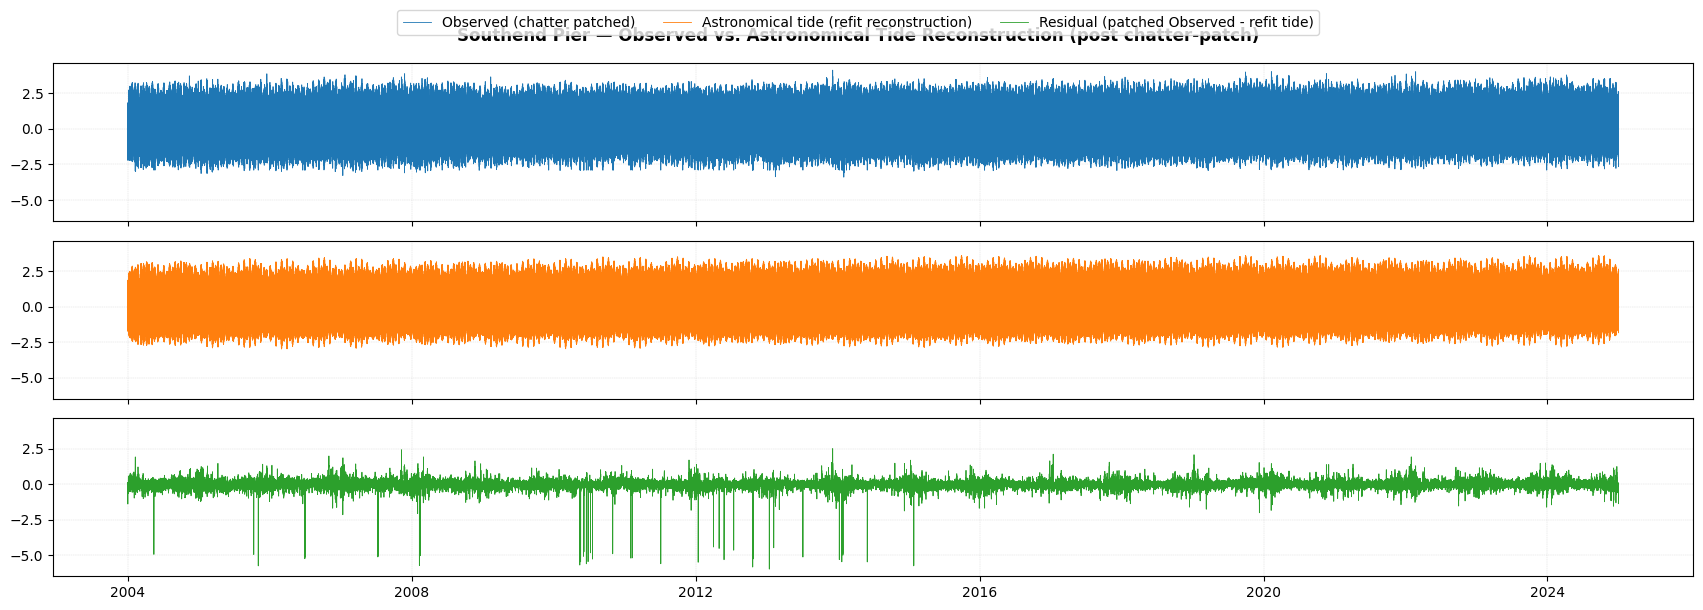

Saved -> ..\outputs\temporal_eda\southend_overview_post_chatter_patch.png


In [28]:
t_full = obs_patched.index.to_pydatetime()
residual_patched = obs_patched["Observed_ODN"] - tide_h_refit

fig, (ax0, ax1, ax2) = plt.subplots(figsize=(17, 6), nrows=3, sharey=True, sharex=True)

ax0.plot(t_full, obs_patched["Observed_ODN"], label="Observed (chatter patched)", color="C0", linewidth=0.6)
ax1.plot(t_full, tide_h_refit, label="Astronomical tide (refit reconstruction)", color="C1", linewidth=0.6)
ax2.plot(t_full, residual_patched, label="Residual (patched Observed - refit tide)", color="C2", linewidth=0.6)

for ax in (ax0, ax1, ax2):
    ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.5)

fig.suptitle("Southend Pier — Observed vs. Astronomical Tide Reconstruction (post chatter-patch)",
             fontweight="bold")
fig.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()

_overview_path = os.path.join(CHATTER_OUTPUT_DIR, "southend_overview_post_chatter_patch.png")
plt.savefig(_overview_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {_overview_path}")

C:\Users\alfat\AppData\Local\Temp\ipykernel_15324\3730440464.py:5: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  zoom_window = slice(biggest["start"] - pd.Timedelta(days=1), biggest["end"] + pd.Timedelta(days=1))


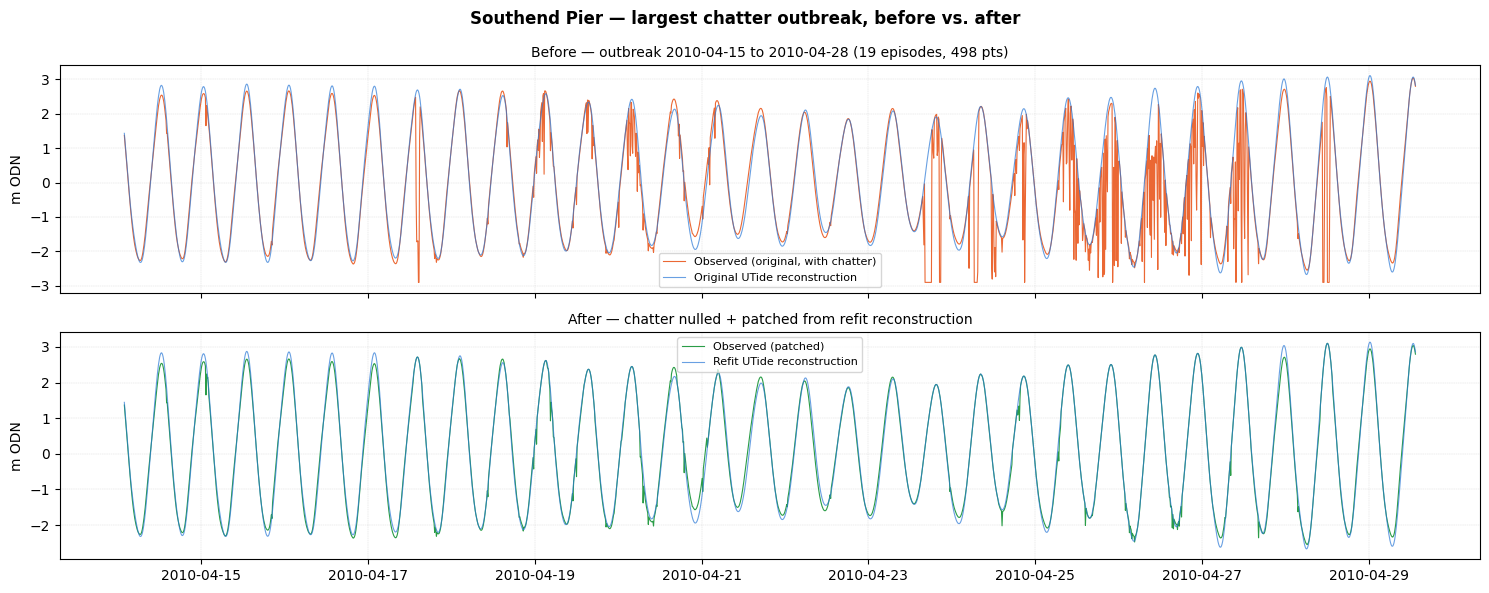

In [29]:
# Zoom into the largest outbreak cluster (from the Stage 1 diagnostic) as a clear
# before/after confirmation, since the full-record view above is too dense to
# see individual episodes at this scale.
biggest = outbreaks.sort_values("n_points", ascending=False).iloc[0]
zoom_window = slice(biggest["start"] - pd.Timedelta(days=1), biggest["end"] + pd.Timedelta(days=1))

fig, (ax0, ax1) = plt.subplots(figsize=(15, 6), nrows=2, sharex=True)

ax0.plot(obs.loc[zoom_window].index, obs.loc[zoom_window, "Observed_ODN"],
         color="#eb6834", linewidth=0.8, label="Observed (original, with chatter)")
ax0.plot(tide_h.loc[zoom_window].index, tide_h.loc[zoom_window],
         color="#2a78d6", linewidth=0.8, alpha=0.7, label="Original UTide reconstruction")
ax0.set_title(f"Before — outbreak {biggest['start']:%Y-%m-%d} to {biggest['end']:%Y-%m-%d} "
              f"({biggest['n_episodes']} episodes, {biggest['n_points']} pts)", fontsize=10)
ax0.set_ylabel("m ODN")
ax0.legend(fontsize=8)

ax1.plot(obs_patched.loc[zoom_window].index, obs_patched.loc[zoom_window, "Observed_ODN"],
         color="#2a9d47", linewidth=0.8, label="Observed (patched)")
ax1.plot(tide_h_refit.loc[zoom_window].index, tide_h_refit.loc[zoom_window],
         color="#2a78d6", linewidth=0.8, alpha=0.7, label="Refit UTide reconstruction")
ax1.set_title("After — chatter nulled + patched from refit reconstruction", fontsize=10)
ax1.set_ylabel("m ODN")
ax1.legend(fontsize=8)

for ax in (ax0, ax1):
    ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.5)

fig.suptitle("Southend Pier — largest chatter outbreak, before vs. after", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CHATTER_OUTPUT_DIR, "southend_biggest_outbreak_before_after.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## Audit Log

`gauge_ts.ipynb` keeps an in-memory `audit` dict (LOAD_AUDIT-style) that already logs the
earlier spike fix under `audit["10_SOUTHEND"]["corrections"]`. That dict only exists for
the lifetime of a run of that notebook, so a durable JSON record of this pass is written
here too, and a matching cell has been added to `gauge_ts.ipynb` (right after the spike-fix
audit entry) so the next full run of that notebook logs this pass automatically.

In [30]:
import json

audit_entry = {
    "pass":                     "chatter_detection_utide_reconstruction",
    "idSite":                   "10_SOUTHEND",
    "date_run":                 pd.Timestamp.now().isoformat(),
    "method":                   "rolling residual std vs UTide reconstruction -> threshold -> "
                                 "null -> refit UTide -> patch from refit reconstruction",
    "roughness_window_samples": ROUGHNESS_WINDOW_SAMPLES,
    "roughness_threshold_m":    ROUGHNESS_THRESHOLD,
    "max_episode_gap":          str(MAX_EPISODE_GAP),
    "n_episodes":               int(len(episodes)),
    "n_points_flagged":         int(episodes["n_points"].sum()),
    "n_points_patched":         int(patch_mask.sum()),
    "pct_of_full_record":       totals["pct_of_full_record"],
    "pct_of_pre2016_record":    totals["pct_of_pre2016_record"],
    "imputation_method":        "utide_reconstruction",
    "review_file":              REVIEW_PATH,
    "episode_table_csv":        os.path.join(CHATTER_OUTPUT_DIR, "southend_chatter_episodes.csv"),
    "constituent_comparison_csv": os.path.join(CHATTER_OUTPUT_DIR, "southend_chatter_constituent_comparison.csv"),
}

audit_log_path = os.path.join(CHATTER_OUTPUT_DIR, "southend_chatter_audit_log.json")
with open(audit_log_path, "w") as f:
    json.dump(audit_entry, f, indent=2, default=str)

print(f"Saved durable audit record -> {audit_log_path}")
print(json.dumps(audit_entry, indent=2, default=str))

Saved durable audit record -> ..\outputs\temporal_eda\southend_chatter_audit_log.json
{
  "pass": "chatter_detection_utide_reconstruction",
  "idSite": "10_SOUTHEND",
  "date_run": "2026-07-19T18:47:05.031365",
  "method": "rolling residual std vs UTide reconstruction -> threshold -> null -> refit UTide -> patch from refit reconstruction",
  "roughness_window_samples": 9,
  "roughness_threshold_m": 0.25,
  "max_episode_gap": "0 days 01:00:00",
  "n_episodes": 719,
  "n_points_flagged": 9586,
  "n_points_patched": 9586,
  "pct_of_full_record": 0.8212,
  "pct_of_pre2016_record": 1.4177,
  "imputation_method": "utide_reconstruction",
  "review_file": "../3_Cleaned/10_SOUTHEND_chatter_patched.csv",
  "episode_table_csv": "..\\outputs\\temporal_eda\\southend_chatter_episodes.csv",
  "constituent_comparison_csv": "..\\outputs\\temporal_eda\\southend_chatter_constituent_comparison.csv"
}


# Stuck-Value (Flatline) Fault -- Second Pass

The updated residual plot above still shows deep, one-sided spikes (to +/-5-6 m) concentrated
pre-2016. These are a **different fault** from the chatter above: the gauge repeats one exact
reading (often precisely `-2.900 m ODN`) for anywhere from a few minutes to ~14 hours -- a
stuck float, not oscillation. A constant value against a *moving* tide often produces sharp
roughness at the transition edges, so the chatter pass above already patched most of each
stuck run by accident; what's left is the leftover fragment where the true tide itself was
moving too slowly for the roughness metric to catch it.

Same 4-stage treatment (FLAG / NULL / REFIT / PATCH), applied on top of `obs_patched` (the
chatter-fixed series) so the two fixes compose cleanly. Detection combines two criteria
(see below): a run-length test for the long stuck runs, and a residual-magnitude test for
short leftover fragments that run-length alone misses.

## Stage 1: FLAG

In [31]:
v = obs_patched["Observed_ODN"]
is_same_as_prev = v.eq(v.shift())
run_id = (~is_same_as_prev).cumsum()
run_counts = run_id.value_counts()
run_len = run_id.map(run_counts)  # each point tagged with the length of its run

print("Run-length distribution (distinct runs, by length):")
print(run_counts.value_counts().sort_index().head(20))

# Natural-coincidence baseline: under an iid model, P(run >= 5) should be ~ p^4
# where p is the per-step repeat rate -- essentially never expected to happen.
p_repeat = (run_len >= 2).sum() / len(v)
expected_naive = len(v) * p_repeat**4
actual_ge5 = (run_counts >= 5).sum()
print(f"\nNaive per-step repeat rate: {p_repeat:.5f}")
print(f"Naive expected runs of length >= 5 under an iid model: {expected_naive:.4f}")
print(f"Actual distinct runs of length >= 5: {actual_ge5}  <-- clear anomaly, not chance")

Run-length distribution (distinct runs, by length):


count
1     1099918
2        1823
3          15
4           1
5           3
6           4
7           5
8           2
9           3
10          2
11          2
12          3
13          2
14          4
16          3
18          1
Name: count, dtype: int64

Naive per-step repeat rate: 0.00366
Naive expected runs of length >= 5 under an iid model: 0.0002
Actual distinct runs of length >= 5: 34  <-- clear anomaly, not chance


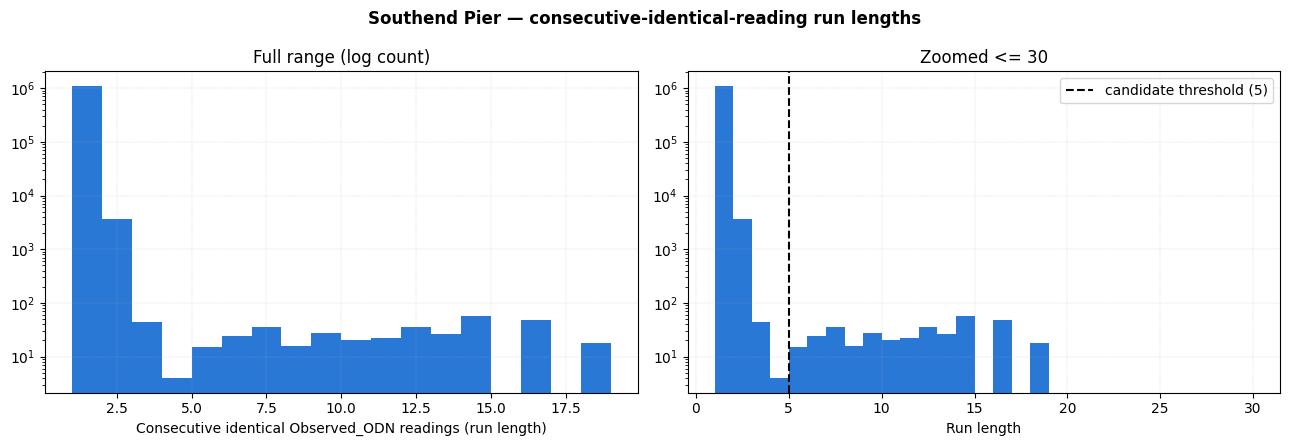

In [32]:
STUCK_RUN_THRESHOLD_FOR_PLOT = 5

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

max_len = int(run_len.max())
axes[0].hist(run_len, bins=range(1, max_len + 2), color="#2a78d6")
axes[0].set_yscale("log")
axes[0].set_xlabel("Consecutive identical Observed_ODN readings (run length)")
axes[0].set_title("Full range (log count)")

axes[1].hist(run_len[run_len <= 30], bins=range(1, 31), color="#2a78d6")
axes[1].set_yscale("log")
axes[1].axvline(STUCK_RUN_THRESHOLD_FOR_PLOT, color="black", linestyle="--",
                 label=f"candidate threshold ({STUCK_RUN_THRESHOLD_FOR_PLOT})")
axes[1].set_xlabel("Run length")
axes[1].set_title("Zoomed <= 30")
axes[1].legend()

for ax in axes:
    ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.5)

fig.suptitle("Southend Pier — consecutive-identical-reading run lengths", fontweight="bold")
plt.tight_layout()
plt.show()

In [33]:
# Run-length alone misses short leftover fragments of the same fault (e.g. where
# the chatter-fix already ate into a long stuck run, or the true tide happened to
# be moving quickly enough that only 1-4 points survived as pure repeats). The
# real signature isn't run length -- it's an astronomically implausible deviation
# from the tide. Check residual magnitude (against the chatter-only refit,
# tide_h_refit) to see if a threshold can catch those fragments too.
residual_vs_refit = obs_patched["Observed_ODN"] - tide_h_refit
abs_residual_vs_refit = residual_vs_refit.abs()

sorted_tail = abs_residual_vs_refit.sort_values(ascending=False)
print(f"230th largest |residual|: {sorted_tail.iloc[229]:.3f} m")
print(f"231st largest |residual|: {sorted_tail.iloc[230]:.3f} m")
print("-> clean gap between an obvious fault cluster and the largest genuine deviation on record")

surge_band = abs_residual_vs_refit[(abs_residual_vs_refit > 1.9) & (abs_residual_vs_refit <= 2.6)]
print(f"\n{len(surge_band)} points with residual in the 1.9-2.6 m band, spanning "
      f"{surge_band.index.min().year}-{surge_band.index.max().year} (not confined to pre-2016).")
print("Values vary smoothly (not repeating) -- this is genuine storm surge (includes the "
      "December 2013 UK East Coast surge), not instrument fault. Must NOT be flagged.")

230th largest |residual|: 4.225 m
231st largest |residual|: 2.516 m
-> clean gap between an obvious fault cluster and the largest genuine deviation on record

84 points with residual in the 1.9-2.6 m band, spanning 2004-2022 (not confined to pre-2016).
Values vary smoothly (not repeating) -- this is genuine storm surge (includes the December 2013 UK East Coast surge), not instrument fault. Must NOT be flagged.


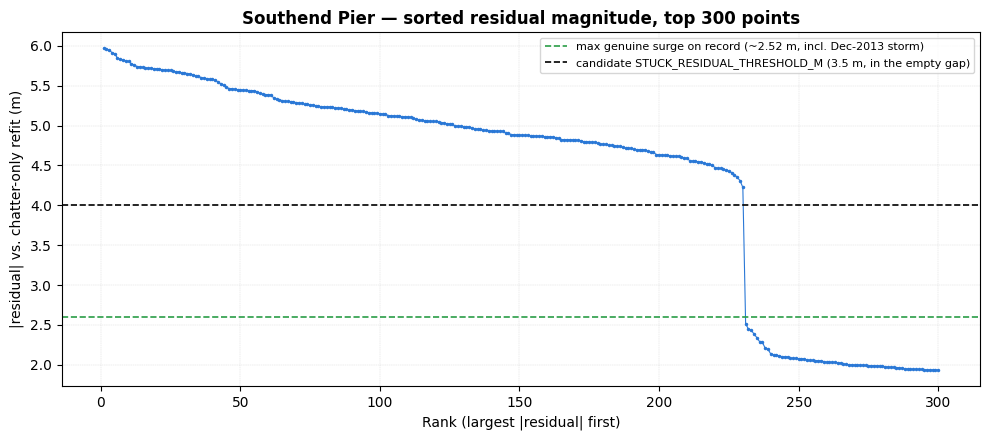

In [34]:
fig, ax = plt.subplots(figsize=(10, 4.5))
top_n = 300
ax.plot(range(1, top_n + 1), sorted_tail.head(top_n).values, marker=".", markersize=3,
        linewidth=0.8, color="#2a78d6")
ax.axhline(2.6, color="#2a9d47", linestyle="--", linewidth=1.2,
           label="max genuine surge on record (~2.52 m, incl. Dec-2013 storm)")
ax.axhline(4.0, color="black", linestyle="--", linewidth=1.2,
           label="candidate STUCK_RESIDUAL_THRESHOLD_M (3.5 m, in the empty gap)")
ax.set_xlabel("Rank (largest |residual| first)")
ax.set_ylabel("|residual| vs. chatter-only refit (m)")
ax.set_title("Southend Pier — sorted residual magnitude, top 300 points", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.5)
plt.tight_layout()
plt.show()

In [35]:
# -- Adjustable thresholds -- inspect the run-length table/histogram and the
# residual rank-plot above before trusting these.
# STUCK_RUN_THRESHOLD catches long stuck runs (natural coincidental repeats vanish
# by length 4; 34 runs of length >=5 exist against a ~0.0002 naive expectation).
# STUCK_RESIDUAL_THRESHOLD_M catches short leftover fragments of the same fault;
# it sits inside the empirical gap between the largest genuine surge on record
# (2.52 m, incl. the Dec-2013 storm) and the fault cluster (starts at 4.22 m), so
# it cannot touch real surge.
STUCK_RUN_THRESHOLD = 5           # consecutive identical readings
STUCK_RESIDUAL_THRESHOLD_M = 3.5  # m, vs. the chatter-only refit reconstruction

is_long_run = run_len >= STUCK_RUN_THRESHOLD
is_large_residual = abs_residual_vs_refit > STUCK_RESIDUAL_THRESHOLD_M

is_stuck_flagged = (is_long_run | is_large_residual) & (~obs_patched["is_chatter_flagged"]) & (~obs_patched["is_imputed"])
assert not (is_stuck_flagged & obs_patched["is_chatter_flagged"]).any()
assert not (is_stuck_flagged & obs_patched["is_imputed"]).any()

print(f"STUCK_RUN_THRESHOLD = {STUCK_RUN_THRESHOLD}, STUCK_RESIDUAL_THRESHOLD_M = {STUCK_RESIDUAL_THRESHOLD_M}")
print(f"  from run length only    : {int(is_long_run.sum()):,} points")
print(f"  from residual only      : {int(is_large_residual.sum()):,} points")
print(f"  combined (OR), flagged  : {int(is_stuck_flagged.sum()):,} points ({100 * is_stuck_flagged.mean():.4f}% of record)")

episodes_stuck = group_into_episodes(is_stuck_flagged, MAX_EPISODE_GAP)
episodes_stuck.insert(0, "episode_id", range(1, len(episodes_stuck) + 1))
episodes_stuck

STUCK_RUN_THRESHOLD = 5, STUCK_RESIDUAL_THRESHOLD_M = 3.5
  from run length only    : 343 points
  from residual only      : 230 points
  combined (OR), flagged  : 388 points (0.0351% of record)


,episode_id,start,end,duration_hours,n_points
0,1,2004-05-14 09:20:00,2004-05-14 09:40:00,0.333333,3
1,2,2005-10-10 03:00:00,2005-10-10 05:10:00,2.166667,14
2,3,2005-10-10 08:40:00,2005-10-10 10:50:00,2.166667,14
3,4,2005-11-02 12:30:00,2005-11-02 12:50:00,0.333333,3
4,5,2005-12-30 16:40:00,2005-12-30 18:50:00,2.166667,14
5,6,2006-06-19 12:10:00,2006-06-19 12:50:00,0.666667,5
6,7,2006-06-30 02:30:00,2006-06-30 03:40:00,1.166667,8
7,8,2006-07-01 03:40:00,2006-07-01 04:00:00,0.333333,3
8,9,2007-07-10 20:40:00,2007-07-10 21:00:00,0.333333,3
9,10,2007-07-11 01:10:00,2007-07-11 04:00:00,2.833333,18


In [36]:
total_flagged_hours_stuck = episodes_stuck["duration_hours"].sum() if len(episodes_stuck) else 0.0
pre2016_flagged_hours_stuck = (
    episodes_stuck.loc[episodes_stuck["start"] < CUTOFF_2016, "duration_hours"].sum()
    if len(episodes_stuck) else 0.0
)

totals_stuck = {
    "n_episodes":            int(len(episodes_stuck)),
    "total_points_flagged":  int(episodes_stuck["n_points"].sum()) if len(episodes_stuck) else 0,
    "total_hours_flagged":   round(float(total_flagged_hours_stuck), 2),
    "pct_of_full_record":    round(100 * total_flagged_hours_stuck / record_hours, 4),
    "pct_of_pre2016_record": round(100 * pre2016_flagged_hours_stuck / pre2016_hours, 4) if pre2016_hours else float("nan"),
}

print("Episode totals (stuck-value):")
for k, val in totals_stuck.items():
    print(f"  {k}: {val}")

episodes_stuck.to_csv(os.path.join(CHATTER_OUTPUT_DIR, "southend_stuck_episodes.csv"), index=False)
pd.DataFrame([totals_stuck]).to_csv(os.path.join(CHATTER_OUTPUT_DIR, "southend_stuck_summary.csv"), index=False)
print(f"\nSaved episode table -> {CHATTER_OUTPUT_DIR}/southend_stuck_episodes.csv")
print(f"Saved totals        -> {CHATTER_OUTPUT_DIR}/southend_stuck_summary.csv")

Episode totals (stuck-value):
  n_episodes: 54
  total_points_flagged: 388
  total_hours_flagged: 55.67
  pct_of_full_record: 0.0302
  pct_of_pre2016_record: 0.053

Saved episode table -> ..\outputs\temporal_eda/southend_stuck_episodes.csv
Saved totals        -> ..\outputs\temporal_eda/southend_stuck_summary.csv


## Stage 2: NULL

Working on a new copy, `obs_patched2`, built from `obs_patched` (the chatter-fixed series) —
so this pass composes on top of the previous fix rather than re-detecting it.

In [37]:
obs_patched2 = obs_patched.copy()
obs_patched2["is_stuck_flagged"] = is_stuck_flagged

assert not (obs_patched2["is_stuck_flagged"] & obs_patched2["is_chatter_flagged"]).any()
assert not (obs_patched2["is_stuck_flagged"] & obs_patched2["is_imputed"]).any()

n_odn_nan_before2 = obs_patched2["Observed_ODN"].isna().sum()
obs_patched2.loc[obs_patched2["is_stuck_flagged"], ["Observed", "Observed_ODN"]] = np.nan
n_odn_nan_after2 = obs_patched2["Observed_ODN"].isna().sum()

print(f"is_stuck_flagged   : {int(obs_patched2['is_stuck_flagged'].sum()):,} rows")
print(f"Observed_ODN NaNs  : {n_odn_nan_before2:,} -> {n_odn_nan_after2:,} (+{n_odn_nan_after2 - n_odn_nan_before2:,})")

# Prior corrections (is_imputed, is_chatter_flagged rows) must stay untouched.
_prior_mask = obs_patched["is_imputed"] | obs_patched["is_chatter_flagged"]
unchanged2 = obs_patched.loc[_prior_mask, ["Observed", "Observed_ODN"]].equals(
    obs_patched2.loc[_prior_mask, ["Observed", "Observed_ODN"]]
)
print(f"Prior corrections (is_imputed / is_chatter_flagged) unchanged: {unchanged2}")

is_stuck_flagged   : 388 rows
Observed_ODN NaNs  : 0 -> 388 (+388)
Prior corrections (is_imputed / is_chatter_flagged) unchanged: True


## Stage 3: REFIT

Refit on `obs_patched2`; same `len(coef["weights"])` check as before confirms NaNs are
dropped from the fit, not coerced to zero. Constituent deltas are measured against the
Stage-3 chatter refit (`coef_refit`/`tide_h_refit`), since that's the "before" state this
pass is building on.

In [38]:
n_valid_input2 = obs_patched2["Observed_ODN"].notna().sum()

coef_refit2 = utide.solve(
    obs_patched2.index, obs_patched2["Observed_ODN"], lat=site_lat, method="ols", conf_int="none"
)
n_used_by_solve2 = len(coef_refit2["weights"])
print(f"obs_patched2: {len(obs_patched2):,} rows total, {n_valid_input2:,} valid (non-NaN) Observed_ODN")
print(f"utide.solve internally used: {n_used_by_solve2:,} rows "
      f"(matches valid count: {n_used_by_solve2 == n_valid_input2})")

tide_refit2 = utide.reconstruct(obs_patched2.index, coef_refit2, verbose=False)
tide_h_refit2 = pd.Series(tide_refit2.h, index=obs_patched2.index, name="Astronomical_tide_refit2")

print(f"\n{len(coef_refit2['name'])} constituents resolved "
      f"(chatter-only refit resolved {len(coef_refit['name'])})")

solve: matrix prep ... 

solution ... 

done.
obs_patched2: 1,103,956 rows total, 1,103,568 valid (non-NaN) Observed_ODN
utide.solve internally used: 1,103,568 rows (matches valid count: True)



68 constituents resolved (chatter-only refit resolved 68)


In [39]:
constituents_refit2 = pd.DataFrame({
    "constituent": coef_refit2["name"],
    "amplitude_m_refit2": coef_refit2["A"],
    "phase_deg_refit2": coef_refit2["g"],
    "PE_percent_refit2": coef_refit2["PE"],
})

constituents_refit_renamed = constituents_refit.rename(columns={
    "amplitude_m_refit": "amplitude_m_before",
    "phase_deg_refit": "phase_deg_before",
    "PE_percent_refit": "PE_percent_before",
})

constituent_comparison2 = constituents_refit_renamed.merge(
    constituents_refit2, on="constituent", how="outer"
)
constituent_comparison2["delta_amplitude_m"] = (
    constituent_comparison2["amplitude_m_refit2"] - constituent_comparison2["amplitude_m_before"]
)
constituent_comparison2["delta_phase_deg"] = (
    constituent_comparison2["phase_deg_refit2"] - constituent_comparison2["phase_deg_before"]
)
constituent_comparison2["delta_PE_percent"] = (
    constituent_comparison2["PE_percent_refit2"] - constituent_comparison2["PE_percent_before"]
)
constituent_comparison2 = constituent_comparison2.sort_values(
    "PE_percent_before", ascending=False, na_position="last"
).reset_index(drop=True)

print(f"Largest |delta_amplitude_m|: {constituent_comparison2['delta_amplitude_m'].abs().max():.6f} m")
print(f"Largest |delta_phase_deg|:   {constituent_comparison2['delta_phase_deg'].abs().max():.6f} deg")

constituent_comparison2.to_csv(
    os.path.join(CHATTER_OUTPUT_DIR, "southend_stuck_constituent_comparison.csv"), index=False
)
print(f"\nSaved -> {CHATTER_OUTPUT_DIR}/southend_stuck_constituent_comparison.csv")

constituent_comparison2.head(15)

Largest |delta_amplitude_m|: 0.001753 m
Largest |delta_phase_deg|:   22.910674 deg

Saved -> ..\outputs\temporal_eda/southend_stuck_constituent_comparison.csv


,constituent,amplitude_m_before,phase_deg_before,PE_percent_before,amplitude_m_refit2,phase_deg_refit2,PE_percent_refit2,delta_amplitude_m,delta_phase_deg,delta_PE_percent
0,M2,2.055791,350.894701,87.157767,2.057544,350.889739,87.165224,0.001753,-0.004962,0.007457
1,S2,0.590952,48.005208,7.201991,0.590906,48.079205,7.189211,-0.000046,0.073997,-0.012780
2,N2,0.347305,326.741199,2.487542,0.347573,326.773120,2.487352,0.000268,0.031921,-0.000189
3,K2,0.174321,46.964462,0.626681,0.174089,46.955533,0.624004,-0.000232,-0.008929,-0.002677
4,MU2,0.134333,88.147823,0.372144,0.134492,88.539032,0.372425,0.000159,0.391209,0.000280
5,L2,0.133700,5.067664,0.368648,0.133731,5.154033,0.368221,0.000031,0.086369,-0.000427
6,O1,0.129918,188.078334,0.348089,0.130060,188.076405,0.348285,0.000142,-0.001929,0.000196
7,K1,0.114396,10.171854,0.269880,0.114155,10.132145,0.268308,-0.000241,-0.039709,-0.001572
8,M4,0.113850,355.471207,0.267309,0.115404,355.060166,0.274212,0.001554,-0.411041,0.006903
9,NU2,0.106577,317.102524,0.234248,0.106681,317.239275,0.234325,0.000104,0.136751,0.000077


In [40]:
# Goodness-of-fit on clean points only (excludes is_imputed, is_chatter_flagged,
# and is_stuck_flagged) -- comparing the chatter-only refit against this refit.
clean_mask2 = (~is_flagged) & (~obs["is_imputed"]) & (~is_stuck_flagged)

resid_before_clean = (obs["Observed_ODN"] - tide_h_refit)[clean_mask2]
resid_after_clean = (obs["Observed_ODN"] - tide_h_refit2)[clean_mask2]

print("Residual std, evaluated on clean points only:")
print(f"  before (chatter-only refit) : {resid_before_clean.std():.4f} m")
print(f"  after (chatter+stuck refit) : {resid_after_clean.std():.4f} m")
print(f"  change                      : {resid_after_clean.std() - resid_before_clean.std():+.4f} m")

Residual std, evaluated on clean points only:
  before (chatter-only refit) : 0.2390 m
  after (chatter+stuck refit) : 0.2390 m
  change                      : -0.0000 m


## Stage 4: PATCH

`imputation_method` gets a third, distinct value — `"utide_reconstruction_stuck"` — so the
two UTide-based corrections (chatter vs. stuck-value) stay separately traceable from each
other, not just from the original `"linear"` spike fix.

In [41]:
obs_patched2.loc[obs_patched2["is_stuck_flagged"], "imputation_method"] = "utide_reconstruction_stuck"

patch_mask2 = obs_patched2["is_stuck_flagged"]
n_before_patch2 = obs_patched2.loc[patch_mask2, "Observed_ODN"].isna().sum()

obs_patched2.loc[patch_mask2, "Observed_ODN"] = tide_h_refit2.loc[patch_mask2]
obs_patched2.loc[patch_mask2, "Observed"] = tide_h_refit2.loc[patch_mask2] + odn_offset

n_after_patch2 = obs_patched2.loc[patch_mask2, "Observed_ODN"].isna().sum()

print(f"Patched rows (stuck) : {int(patch_mask2.sum()):,}")
print(f"NaN before patch     : {n_before_patch2:,}")
print(f"NaN after patch      : {n_after_patch2:,}")
print(f"\nimputation_method value counts:")
print(obs_patched2["imputation_method"].value_counts())

other_nan_mask2 = obs_patched2["Observed_ODN"].isna() & ~patch_mask2
print(f"\nOther untouched NaNs remaining (unrelated missing data, left as-is): {int(other_nan_mask2.sum()):,}")

Patched rows (stuck) : 388
NaN before patch     : 388
NaN after patch      : 0

imputation_method value counts:
imputation_method
none                          1093981
utide_reconstruction             9586
utide_reconstruction_stuck        388
linear                              1
Name: count, dtype: int64

Other untouched NaNs remaining (unrelated missing data, left as-is): 0


In [42]:
print("=" * 78)
print("REMINDER: exclude patched points from train/val/test splits")
print("=" * 78)
print(
    "Rows with imputation_method in {'linear', 'utide_reconstruction', "
    "'utide_reconstruction_stuck'} are not real surge observations. Any future\n"
    "split used to score a model's skill against UTide must exclude all three\n"
    "from evaluation (and arguably from training too)."
)

REVIEW_PATH2 = "../3_Cleaned/10_SOUTHEND_chatter_and_stuck_patched.csv"
obs_patched2.to_csv(REVIEW_PATH2)
print(f"\nSaved doubly-patched series for review -> {REVIEW_PATH2}")
print("(3_Cleaned/10_SOUTHEND.csv and the chatter-only review file are both untouched.)")

REMINDER: exclude patched points from train/val/test splits
Rows with imputation_method in {'linear', 'utide_reconstruction', 'utide_reconstruction_stuck'} are not real surge observations. Any future
split used to score a model's skill against UTide must exclude all three
from evaluation (and arguably from training too).



Saved doubly-patched series for review -> ../3_Cleaned/10_SOUTHEND_chatter_and_stuck_patched.csv
(3_Cleaned/10_SOUTHEND.csv and the chatter-only review file are both untouched.)


## QA — Before/After Overlay Plots (stuck-value episodes)

Far fewer episodes than the chatter pass (dozens, not hundreds), so all are shown inline as
well as saved to disk.

Generating 54 before/after QA plots -> ..\outputs\temporal_eda\stuck_episode_qa ...


Done — 54 PNGs saved.


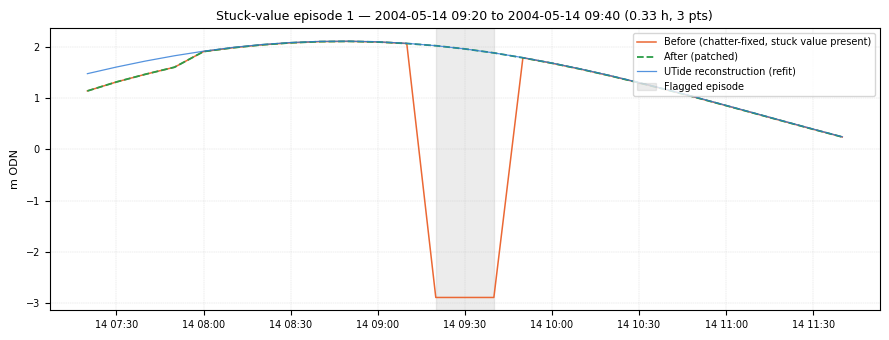

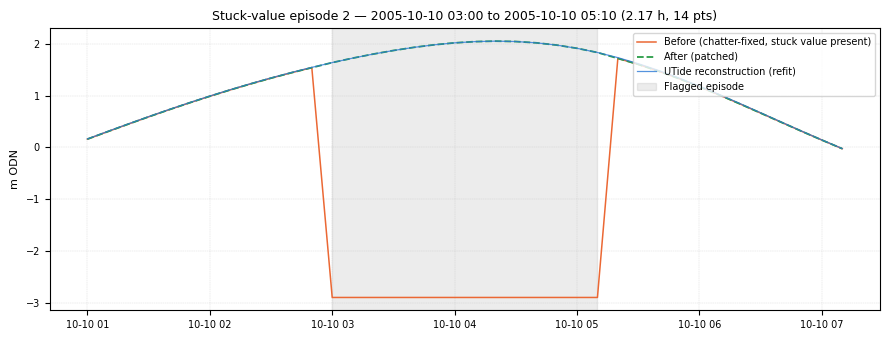

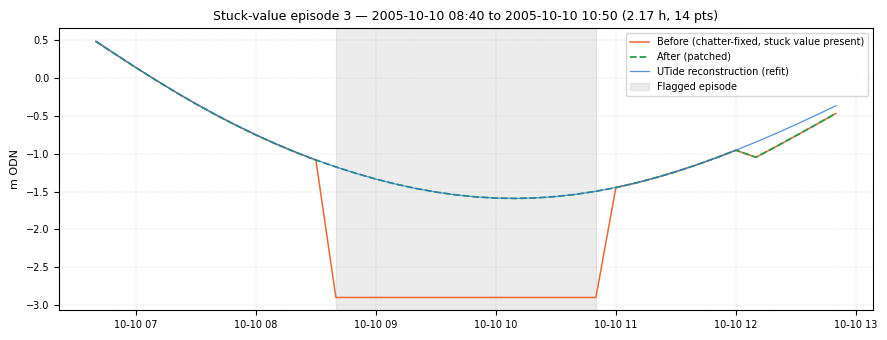

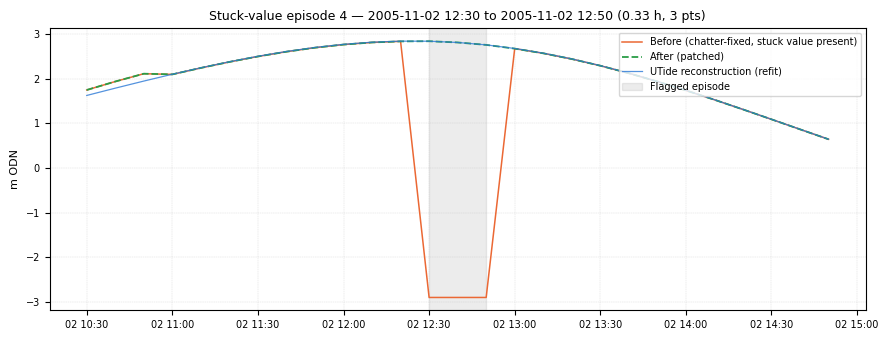

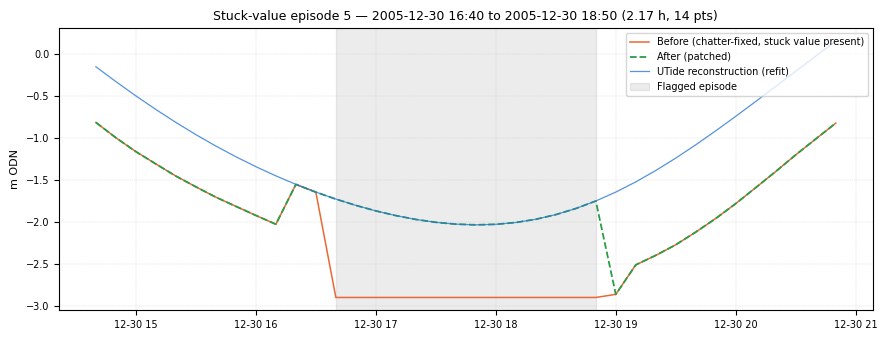

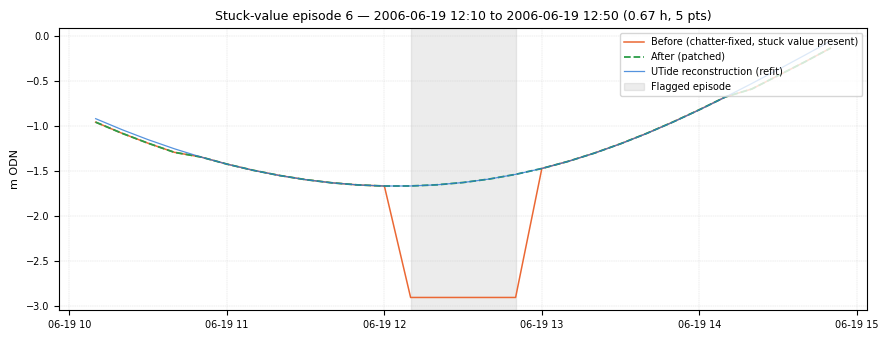

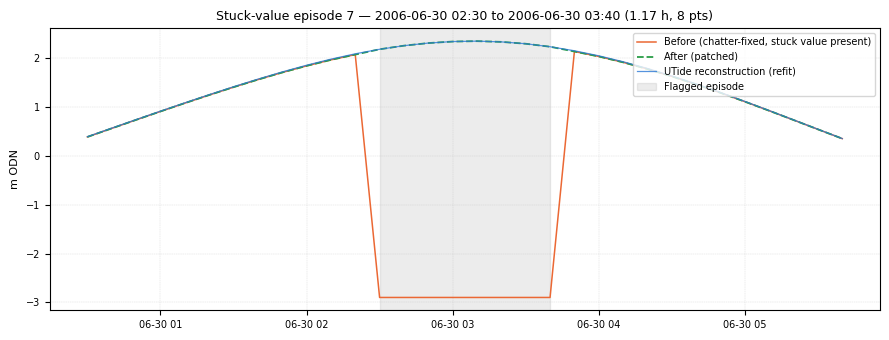

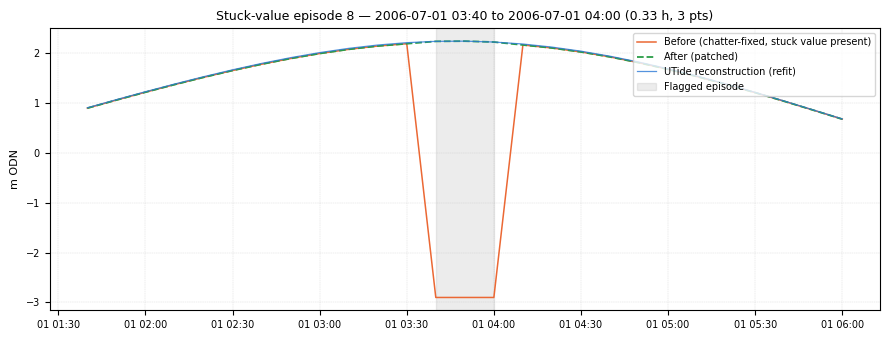

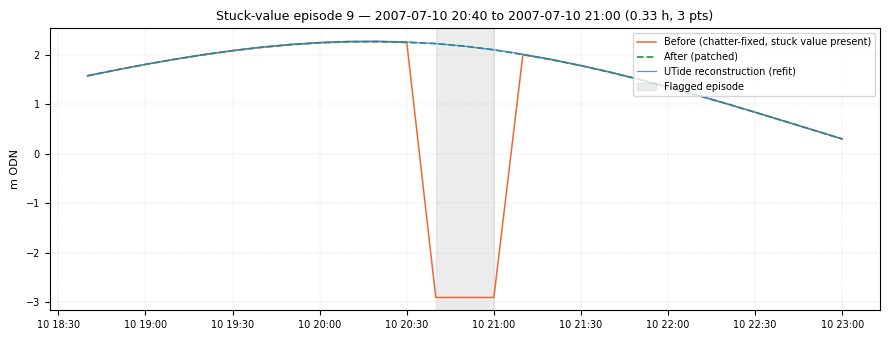

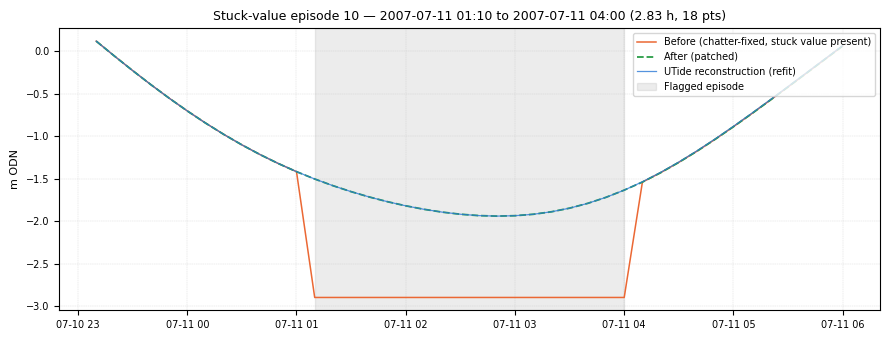

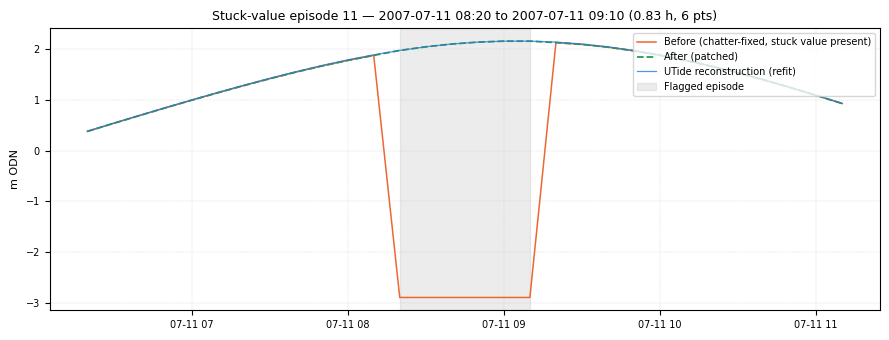

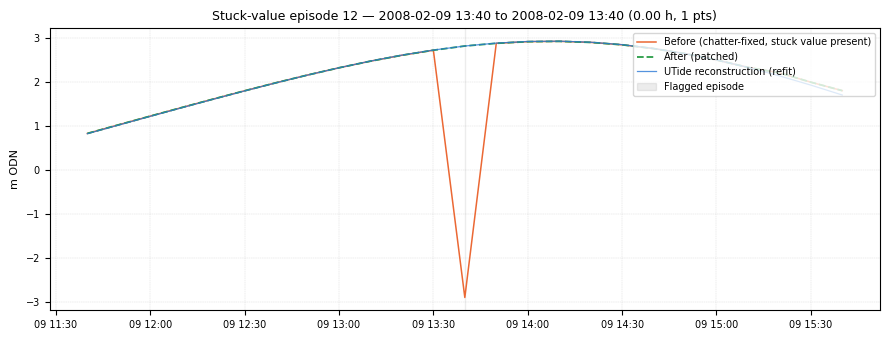

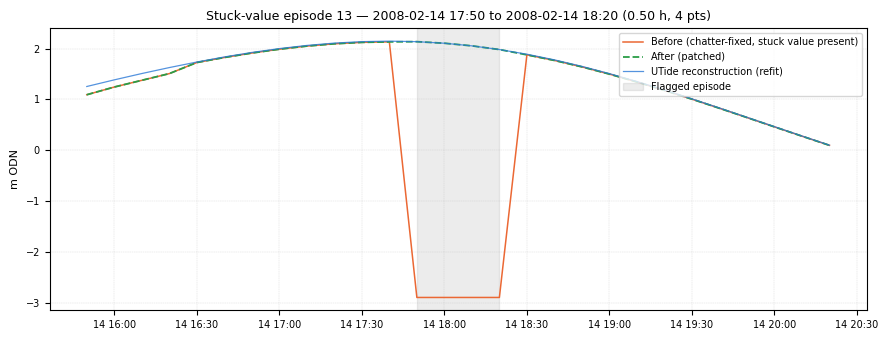

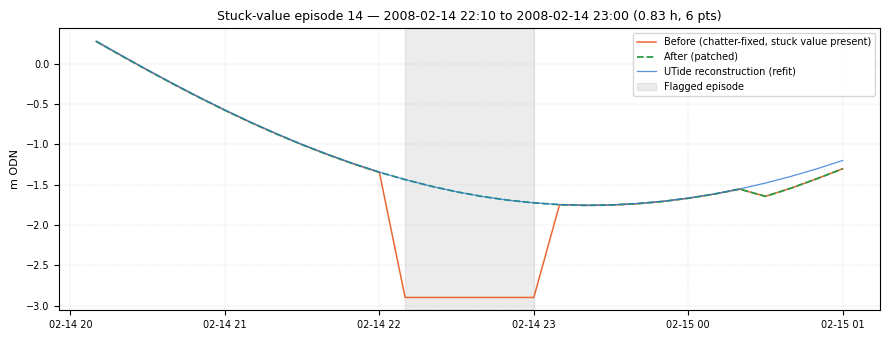

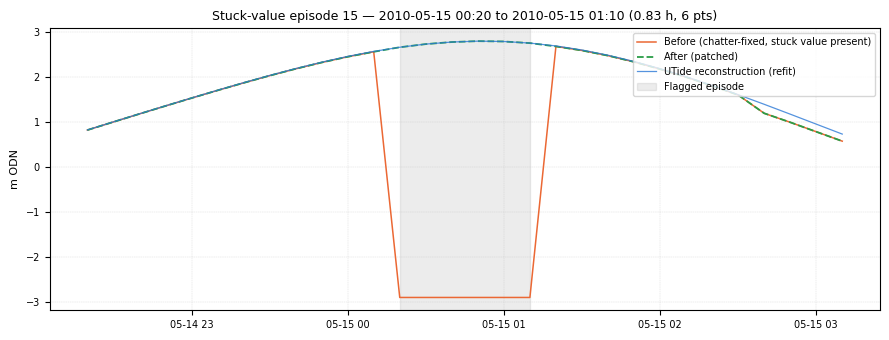

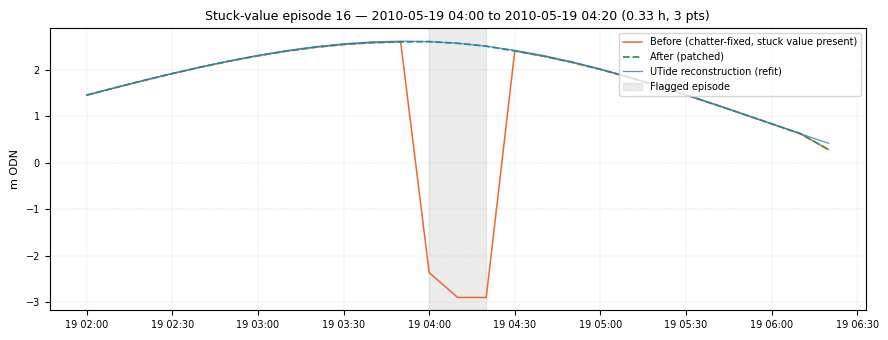

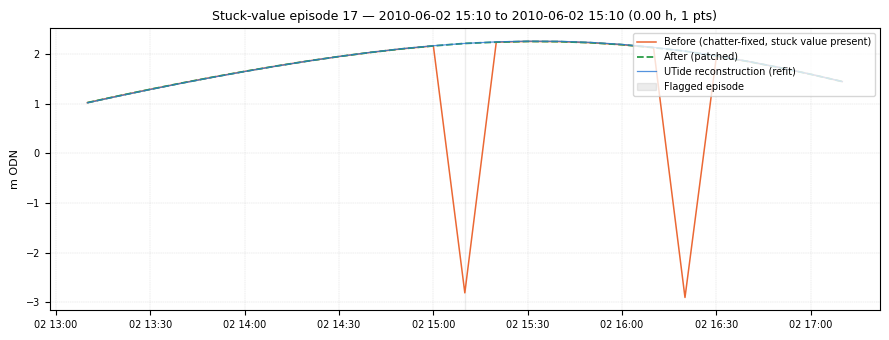

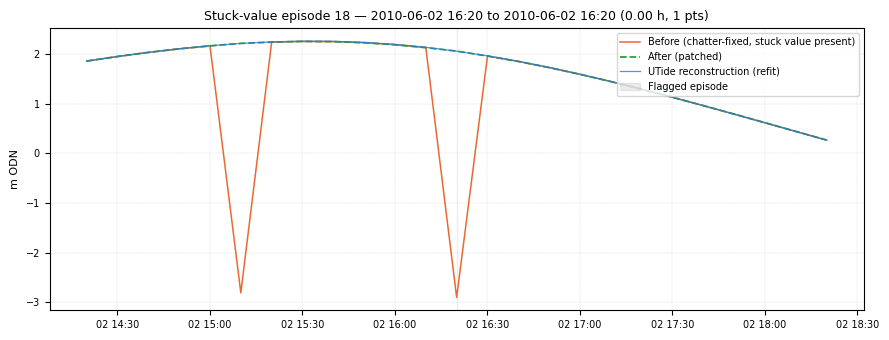

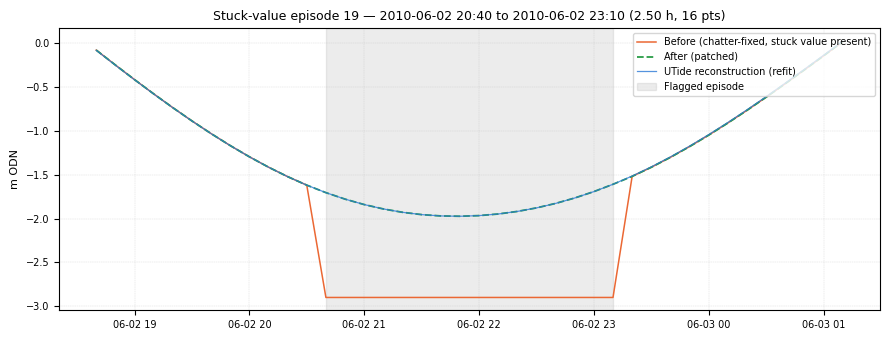

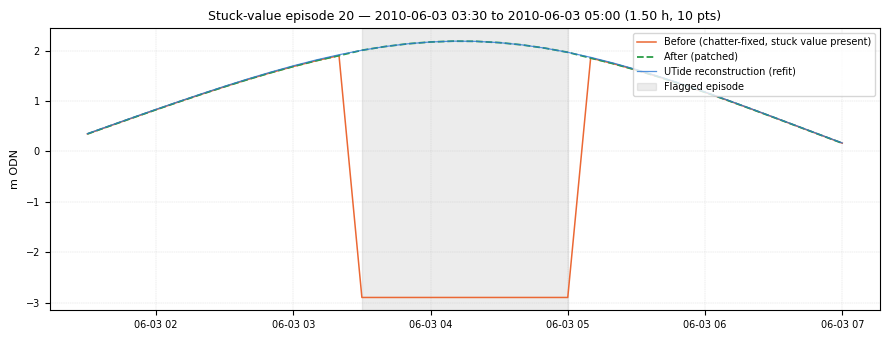

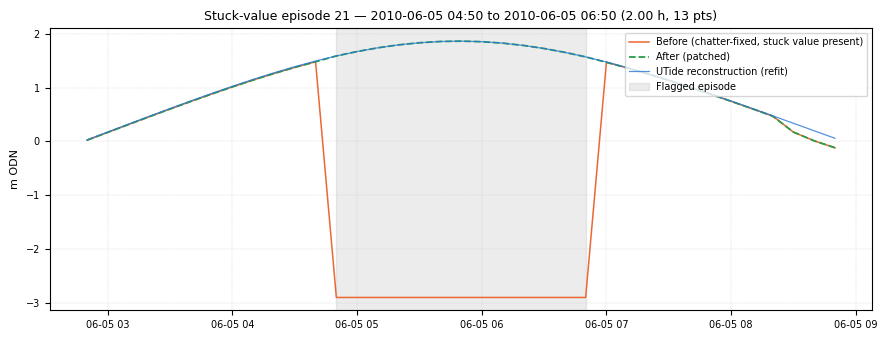

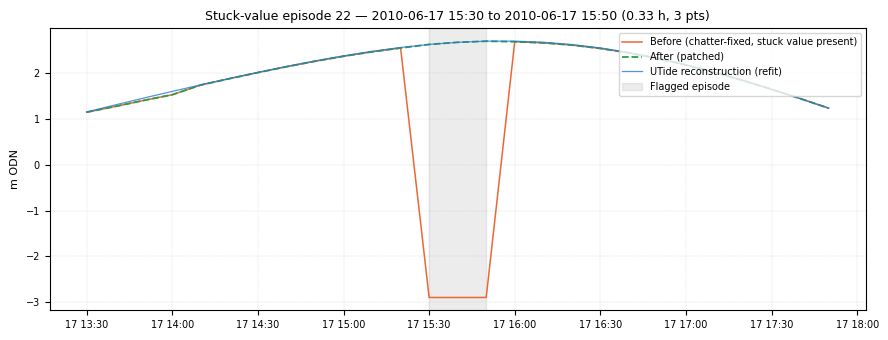

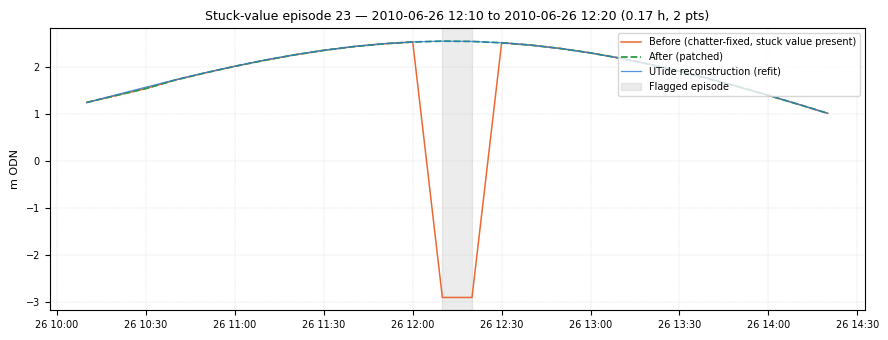

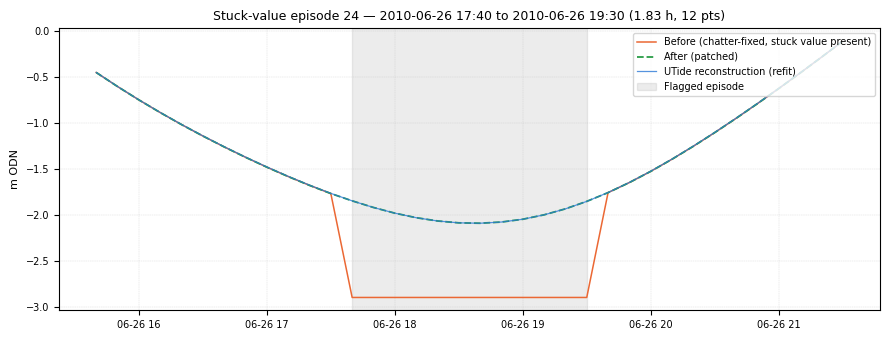

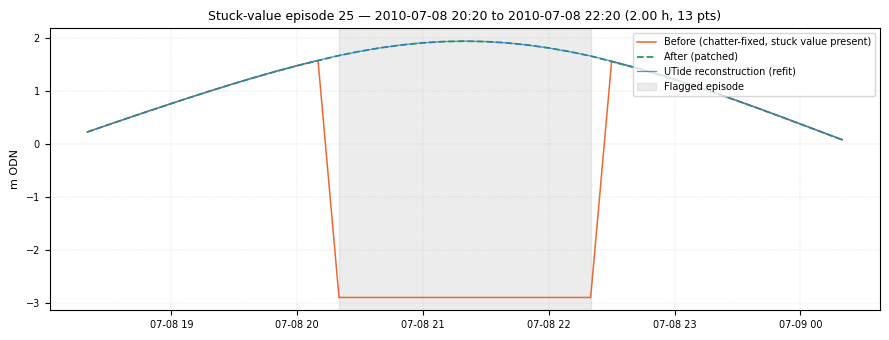

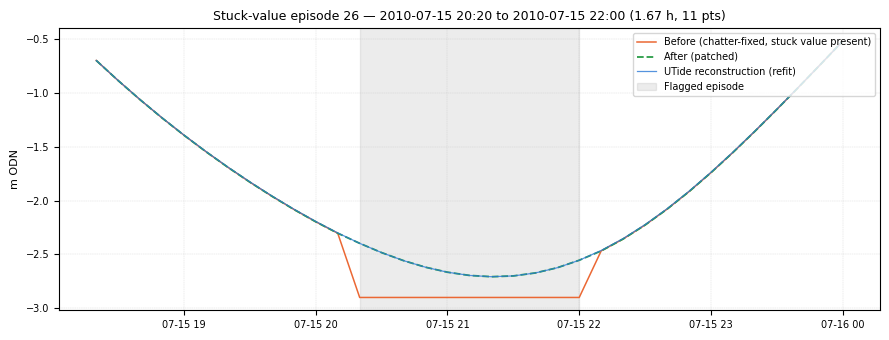

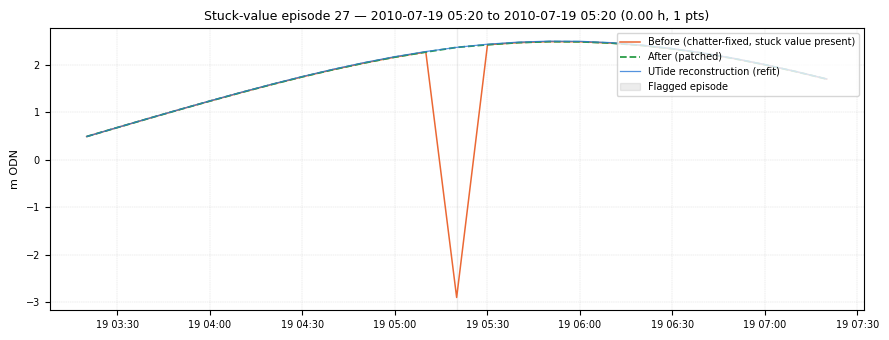

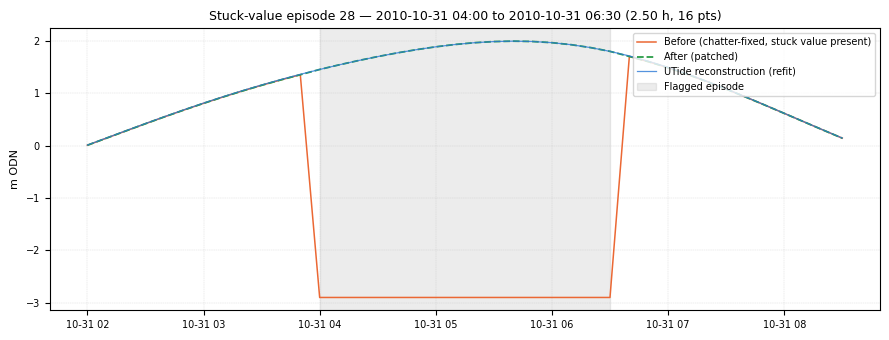

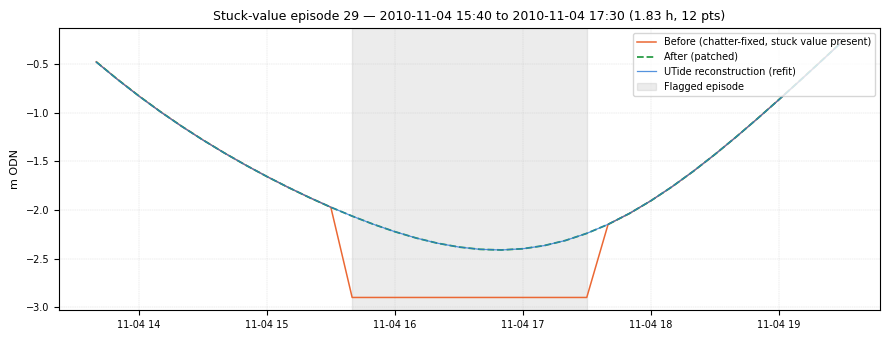

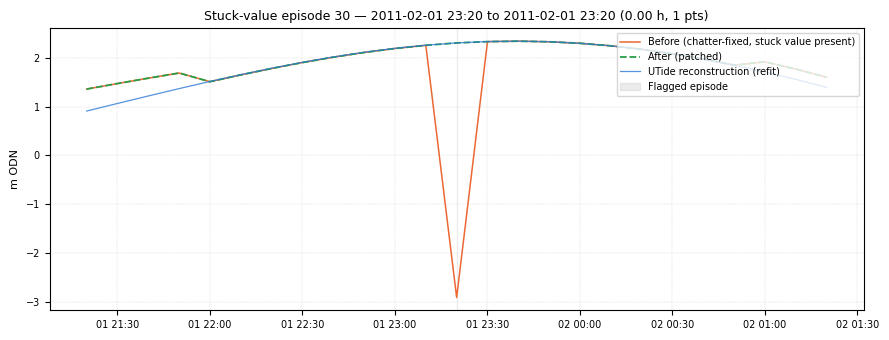

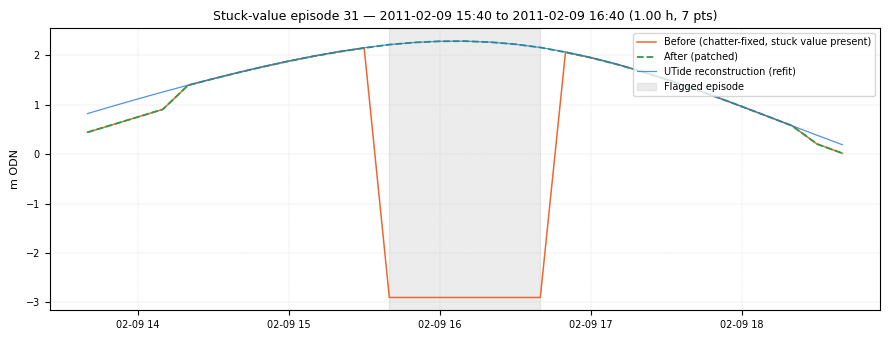

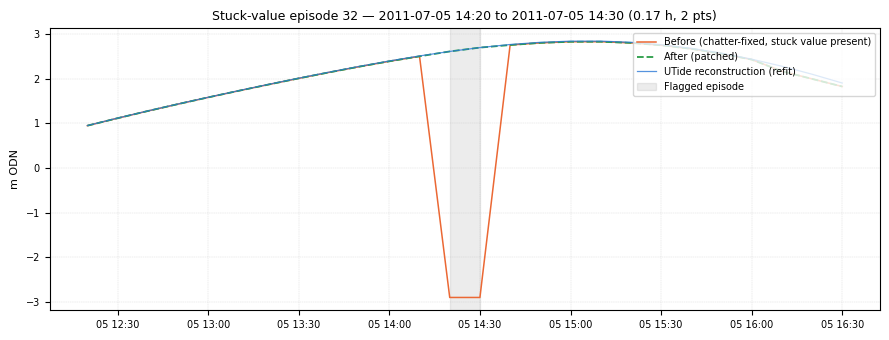

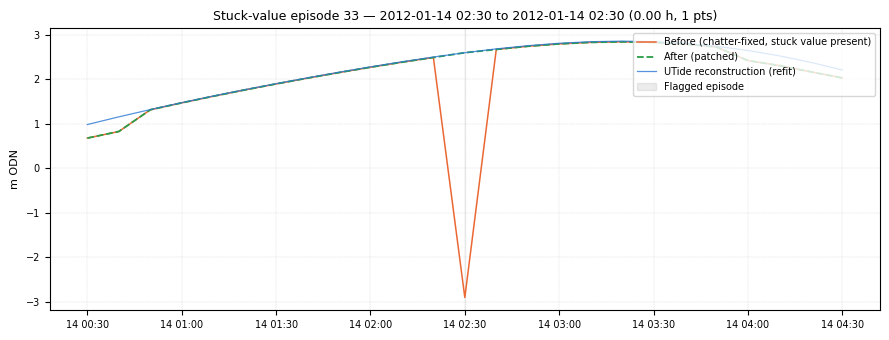

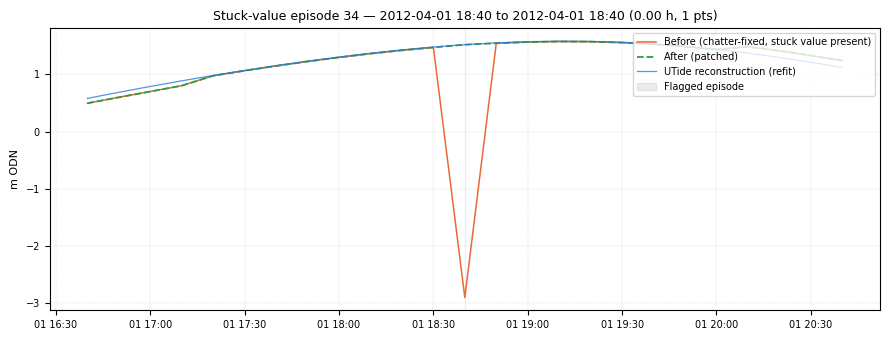

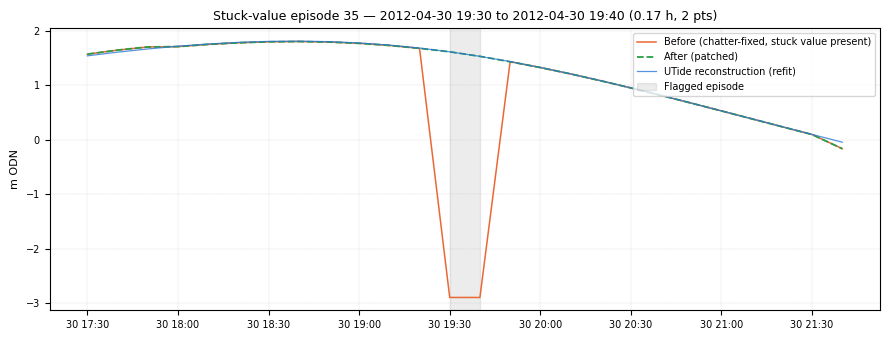

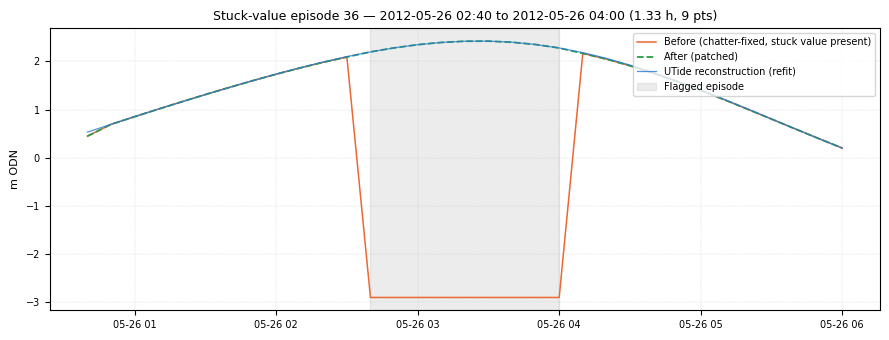

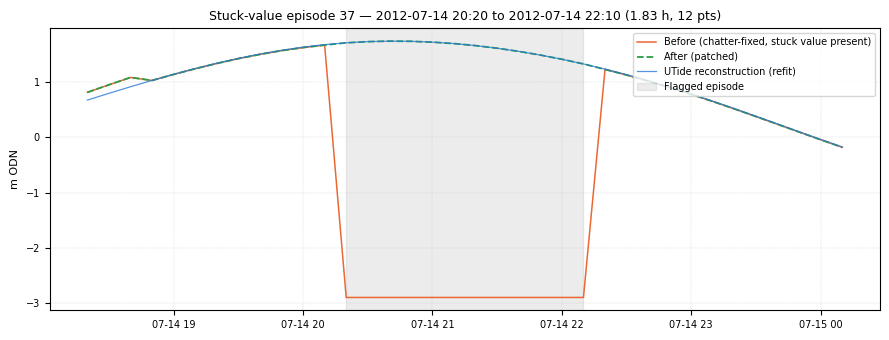

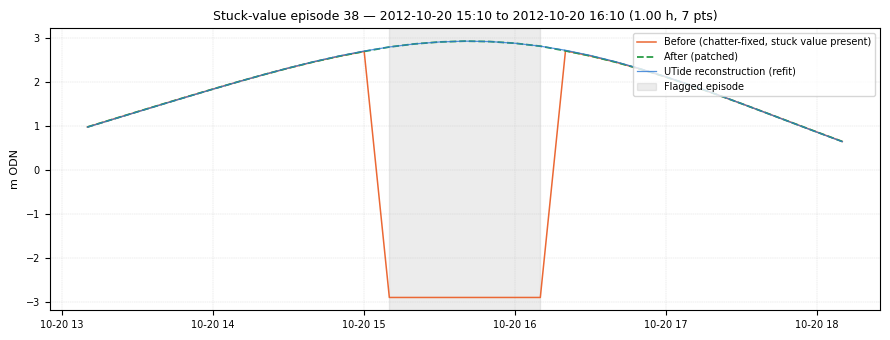

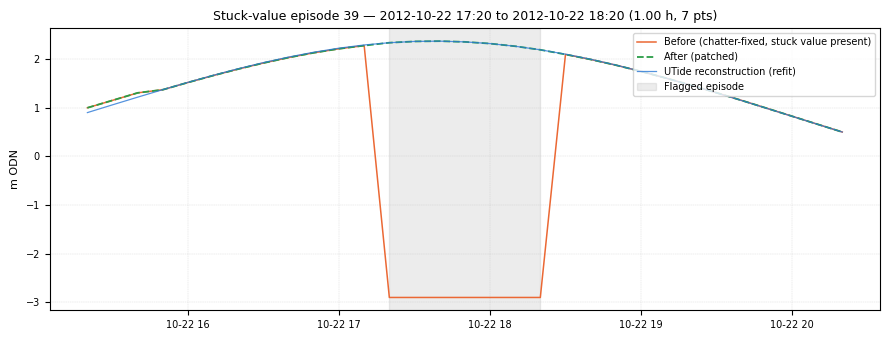

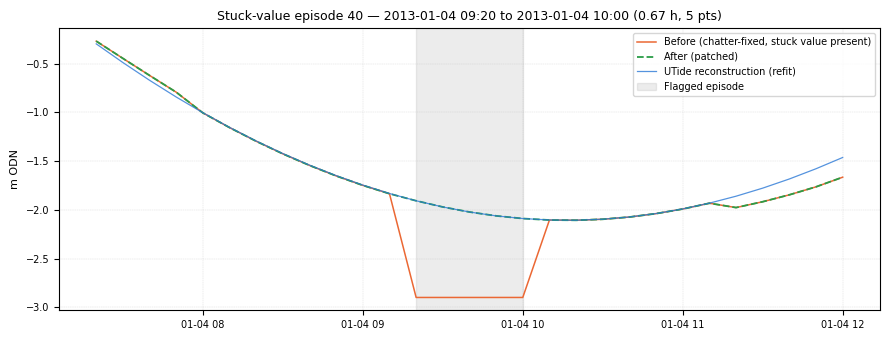

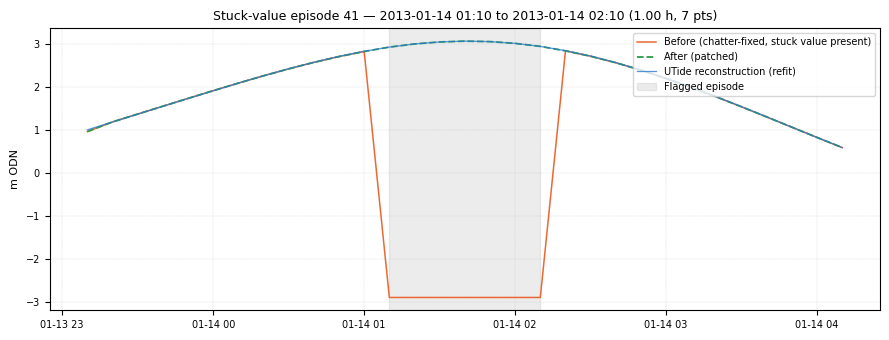

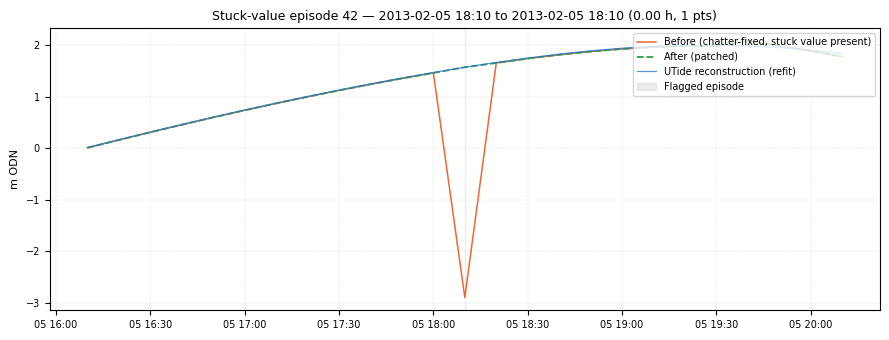

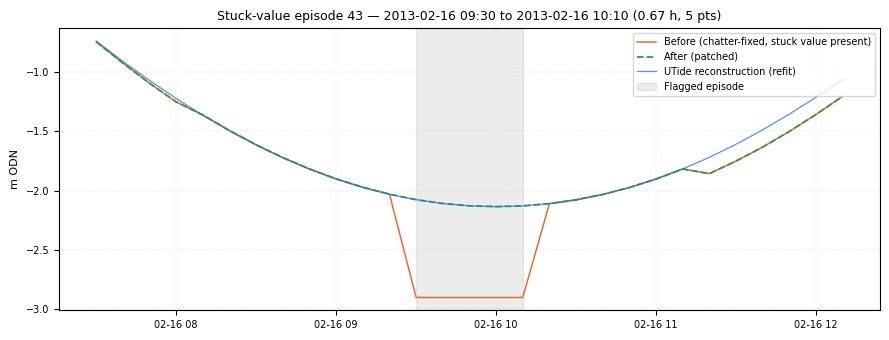

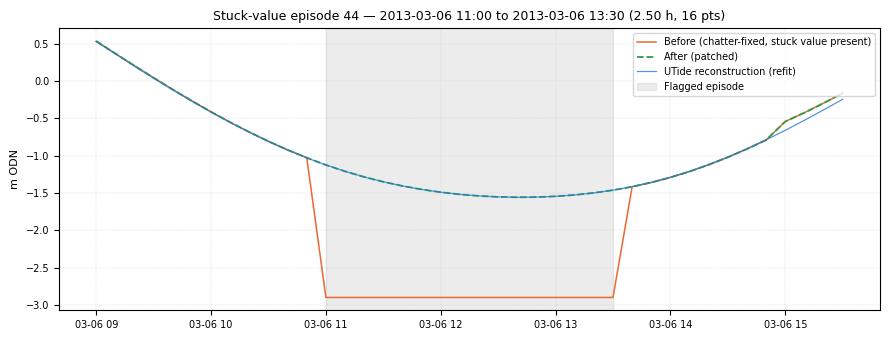

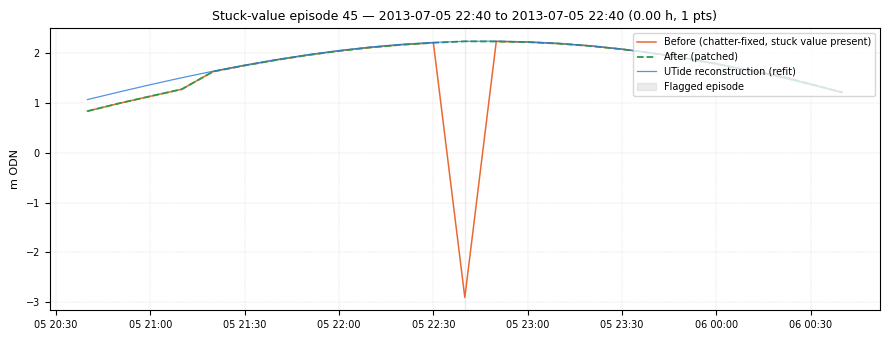

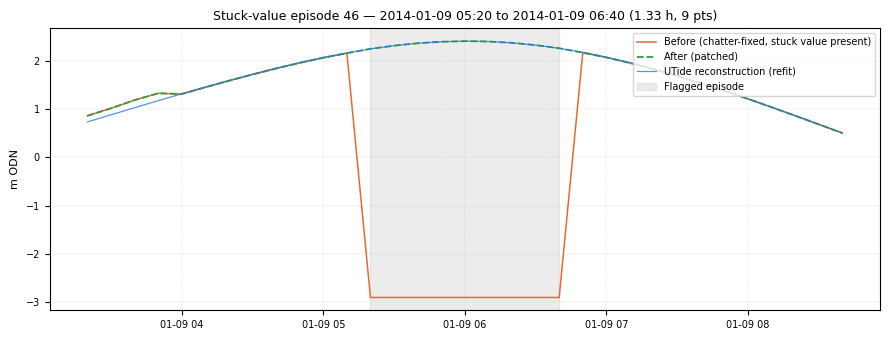

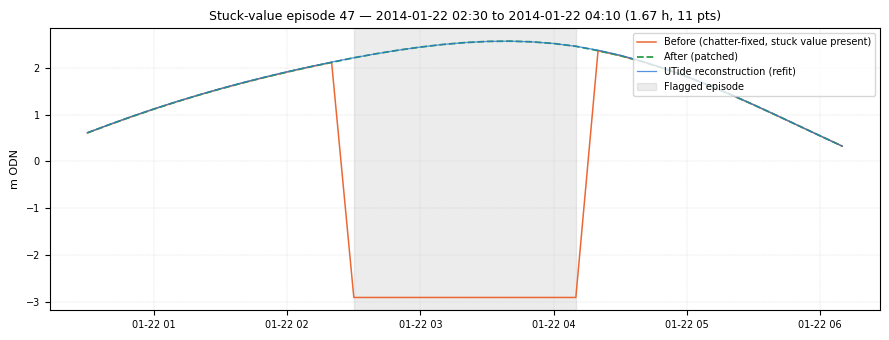

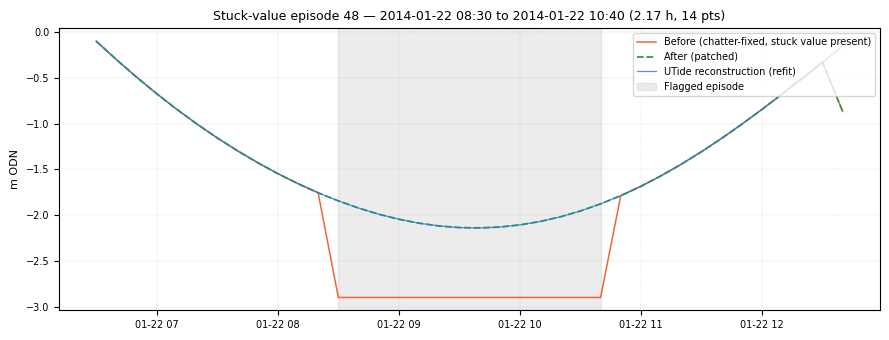

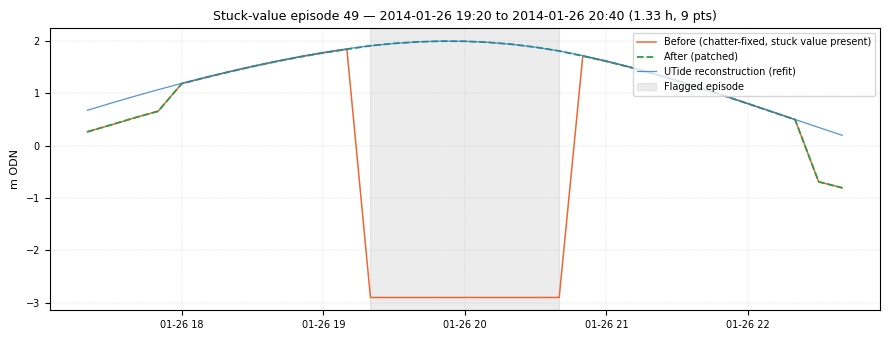

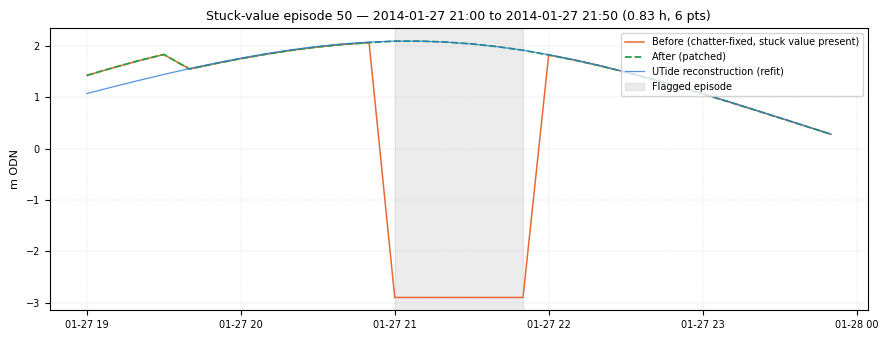

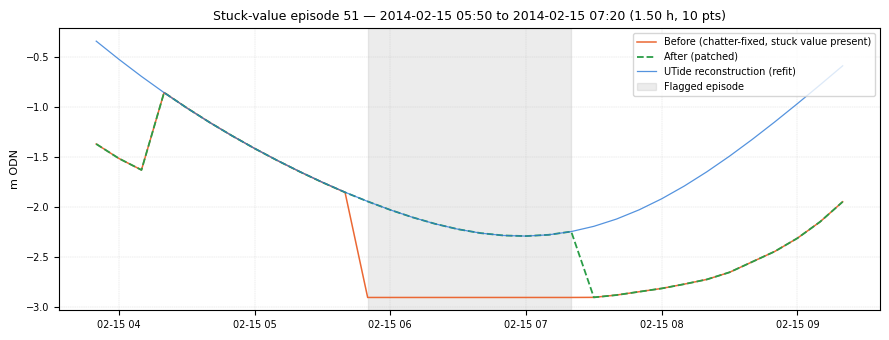

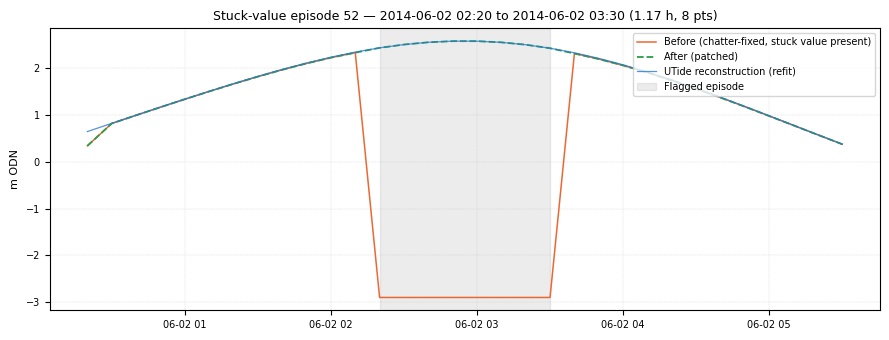

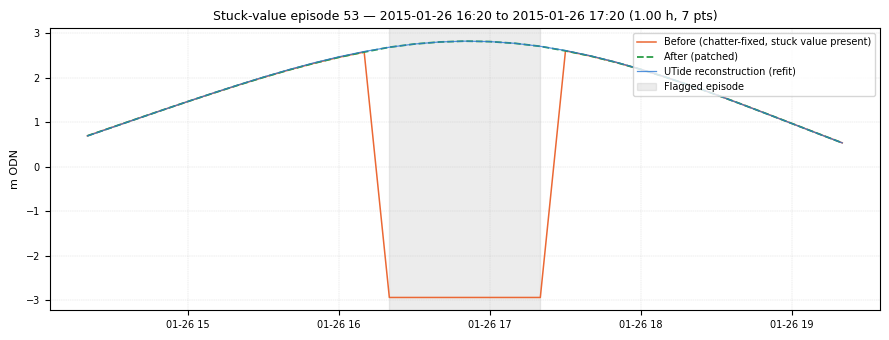

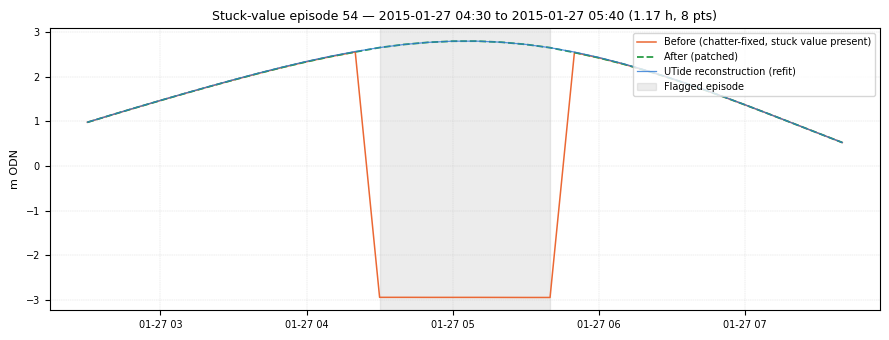

In [43]:
STUCK_QA_DIR = os.path.join(CHATTER_OUTPUT_DIR, "stuck_episode_qa")
os.makedirs(STUCK_QA_DIR, exist_ok=True)


def plot_stuck_episode(row):
    start, end = row["start"], row["end"]
    window = slice(start - PAD, end + PAD)

    before_win = obs_patched.loc[window, "Observed_ODN"]
    after_win = obs_patched2.loc[window, "Observed_ODN"]
    tide_win = tide_h_refit2.loc[window]

    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.plot(before_win.index, before_win, color="#eb6834", linewidth=1.1,
            label="Before (chatter-fixed, stuck value present)")
    ax.plot(after_win.index, after_win, color="#2a9d47", linewidth=1.3, linestyle="--",
            label="After (patched)")
    ax.plot(tide_win.index, tide_win, color="#2a78d6", linewidth=0.9, alpha=0.8,
            label="UTide reconstruction (refit)")
    ax.axvspan(start, end, color="grey", alpha=0.15, label="Flagged episode")
    ax.set_title(
        f"Stuck-value episode {int(row['episode_id'])} — {start:%Y-%m-%d %H:%M} to "
        f"{end:%Y-%m-%d %H:%M} ({row['duration_hours']:.2f} h, {int(row['n_points'])} pts)",
        fontsize=9,
    )
    ax.set_ylabel("m ODN", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.5)
    ax.legend(fontsize=7, loc="upper right")
    fig.tight_layout()
    return fig


print(f"Generating {len(episodes_stuck)} before/after QA plots -> {STUCK_QA_DIR} ...")
for _, row in episodes_stuck.iterrows():
    fig = plot_stuck_episode(row)
    fname = f"stuck_episode_{int(row['episode_id']):04d}_{row['start']:%Y%m%d_%H%M}.png"
    fig.savefig(os.path.join(STUCK_QA_DIR, fname), dpi=110, bbox_inches="tight")
    plt.close(fig)
print(f"Done — {len(episodes_stuck)} PNGs saved.")

for _, row in episodes_stuck.iterrows():
    plot_stuck_episode(row)
    plt.show()

## Updated Full-Record Overview (post chatter + stuck-value patch)

Same three-panel layout, rebuilt on `obs_patched2` + `tide_h_refit2`, to confirm both faults
are gone.

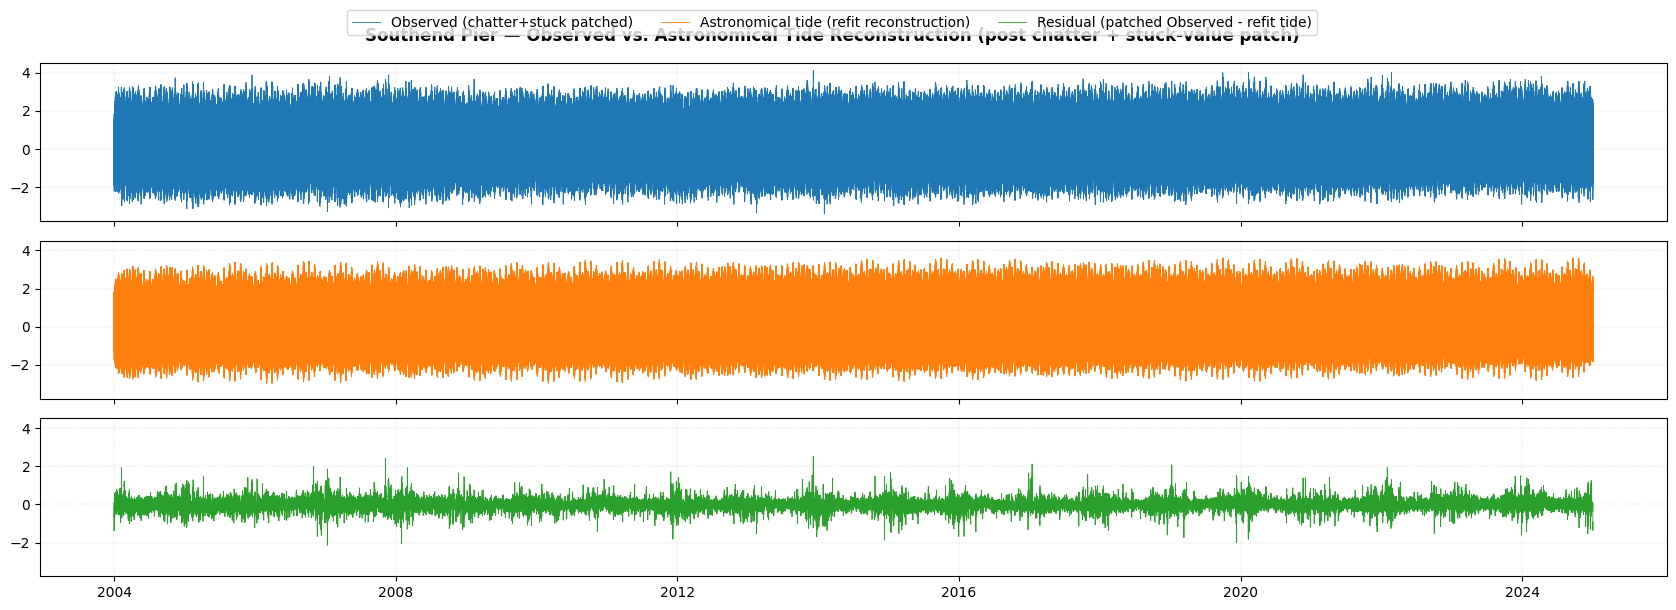

Saved -> ..\outputs\temporal_eda\southend_overview_post_chatter_and_stuck_patch.png


In [44]:
t_full2 = obs_patched2.index.to_pydatetime()
residual_patched2 = obs_patched2["Observed_ODN"] - tide_h_refit2

fig, (ax0, ax1, ax2) = plt.subplots(figsize=(17, 6), nrows=3, sharey=True, sharex=True)

ax0.plot(t_full2, obs_patched2["Observed_ODN"], label="Observed (chatter+stuck patched)", color="C0", linewidth=0.6)
ax1.plot(t_full2, tide_h_refit2, label="Astronomical tide (refit reconstruction)", color="C1", linewidth=0.6)
ax2.plot(t_full2, residual_patched2, label="Residual (patched Observed - refit tide)", color="C2", linewidth=0.6)

for ax in (ax0, ax1, ax2):
    ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.5)

fig.suptitle("Southend Pier — Observed vs. Astronomical Tide Reconstruction (post chatter + stuck-value patch)",
             fontweight="bold")
fig.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()

_overview_path2 = os.path.join(CHATTER_OUTPUT_DIR, "southend_overview_post_chatter_and_stuck_patch.png")
plt.savefig(_overview_path2, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {_overview_path2}")

C:\Users\alfat\AppData\Local\Temp\ipykernel_15324\2429828580.py:3: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  zoom_window2 = slice(biggest_stuck["start"] - pd.Timedelta(hours=6), biggest_stuck["end"] + pd.Timedelta(hours=6))


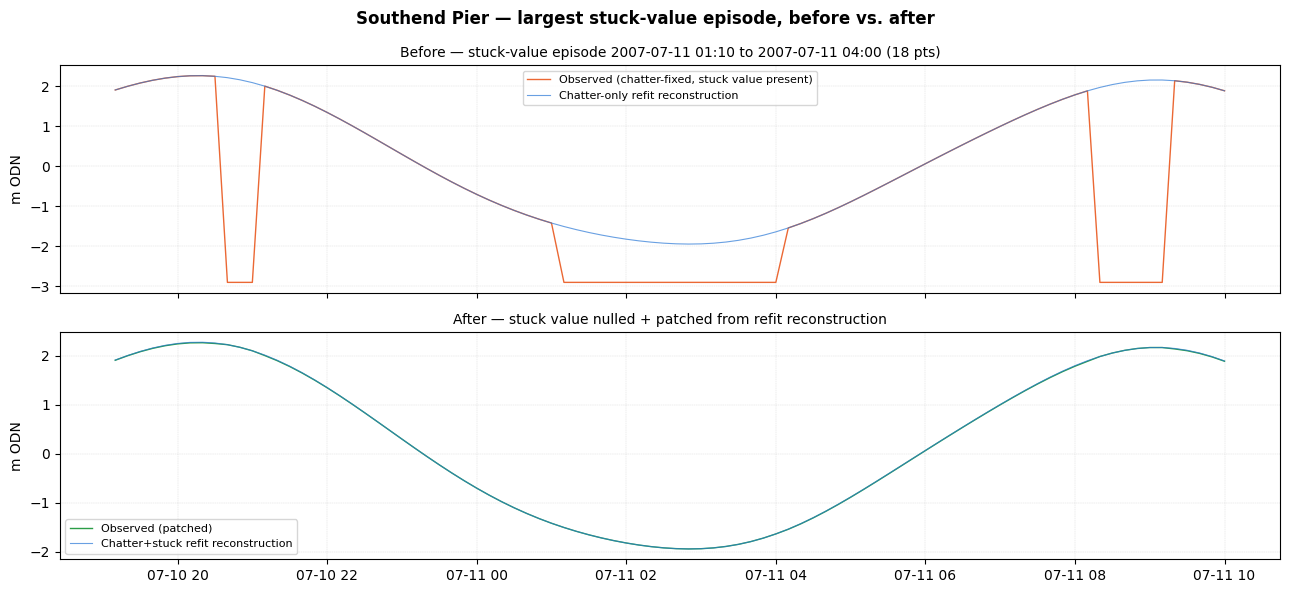

In [45]:
# Zoom into the largest stuck-value episode as a clear before/after confirmation.
biggest_stuck = episodes_stuck.sort_values("n_points", ascending=False).iloc[0]
zoom_window2 = slice(biggest_stuck["start"] - pd.Timedelta(hours=6), biggest_stuck["end"] + pd.Timedelta(hours=6))

fig, (ax0, ax1) = plt.subplots(figsize=(13, 6), nrows=2, sharex=True)

ax0.plot(obs_patched.loc[zoom_window2].index, obs_patched.loc[zoom_window2, "Observed_ODN"],
         color="#eb6834", linewidth=1.0, label="Observed (chatter-fixed, stuck value present)")
ax0.plot(tide_h_refit.loc[zoom_window2].index, tide_h_refit.loc[zoom_window2],
         color="#2a78d6", linewidth=0.8, alpha=0.7, label="Chatter-only refit reconstruction")
ax0.set_title(f"Before — stuck-value episode {biggest_stuck['start']:%Y-%m-%d %H:%M} to "
              f"{biggest_stuck['end']:%Y-%m-%d %H:%M} ({int(biggest_stuck['n_points'])} pts)", fontsize=10)
ax0.set_ylabel("m ODN")
ax0.legend(fontsize=8)

ax1.plot(obs_patched2.loc[zoom_window2].index, obs_patched2.loc[zoom_window2, "Observed_ODN"],
         color="#2a9d47", linewidth=1.0, label="Observed (patched)")
ax1.plot(tide_h_refit2.loc[zoom_window2].index, tide_h_refit2.loc[zoom_window2],
         color="#2a78d6", linewidth=0.8, alpha=0.7, label="Chatter+stuck refit reconstruction")
ax1.set_title("After — stuck value nulled + patched from refit reconstruction", fontsize=10)
ax1.set_ylabel("m ODN")
ax1.legend(fontsize=8)

for ax in (ax0, ax1):
    ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.5)

fig.suptitle("Southend Pier — largest stuck-value episode, before vs. after", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CHATTER_OUTPUT_DIR, "southend_biggest_stuck_episode_before_after.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## Audit Log

In [46]:
audit_entry_stuck = {
    "pass":                     "stuck_value_detection_utide_reconstruction",
    "idSite":                   "10_SOUTHEND",
    "date_run":                 pd.Timestamp.now().isoformat(),
    "method":                   "consecutive-identical-reading run length -> threshold -> "
                                 "null -> refit UTide -> patch from refit reconstruction "
                                 "(applied on top of the chatter-fixed series)",
    "stuck_run_threshold":      STUCK_RUN_THRESHOLD,
    "max_episode_gap":          str(MAX_EPISODE_GAP),
    "n_episodes":               int(len(episodes_stuck)),
    "n_points_flagged":         int(episodes_stuck["n_points"].sum()) if len(episodes_stuck) else 0,
    "n_points_patched":         int(patch_mask2.sum()),
    "pct_of_full_record":       totals_stuck["pct_of_full_record"],
    "pct_of_pre2016_record":    totals_stuck["pct_of_pre2016_record"],
    "imputation_method":        "utide_reconstruction_stuck",
    "review_file":              REVIEW_PATH2,
    "episode_table_csv":        os.path.join(CHATTER_OUTPUT_DIR, "southend_stuck_episodes.csv"),
    "constituent_comparison_csv": os.path.join(CHATTER_OUTPUT_DIR, "southend_stuck_constituent_comparison.csv"),
}

audit_log_path_stuck = os.path.join(CHATTER_OUTPUT_DIR, "southend_stuck_audit_log.json")
with open(audit_log_path_stuck, "w") as f:
    json.dump(audit_entry_stuck, f, indent=2, default=str)

print(f"Saved durable audit record -> {audit_log_path_stuck}")
print(json.dumps(audit_entry_stuck, indent=2, default=str))

Saved durable audit record -> ..\outputs\temporal_eda\southend_stuck_audit_log.json
{
  "pass": "stuck_value_detection_utide_reconstruction",
  "idSite": "10_SOUTHEND",
  "date_run": "2026-07-19T18:48:29.373548",
  "method": "consecutive-identical-reading run length -> threshold -> null -> refit UTide -> patch from refit reconstruction (applied on top of the chatter-fixed series)",
  "stuck_run_threshold": 5,
  "max_episode_gap": "0 days 01:00:00",
  "n_episodes": 54,
  "n_points_flagged": 388,
  "n_points_patched": 388,
  "pct_of_full_record": 0.0302,
  "pct_of_pre2016_record": 0.053,
  "imputation_method": "utide_reconstruction_stuck",
  "review_file": "../3_Cleaned/10_SOUTHEND_chatter_and_stuck_patched.csv",
  "episode_table_csv": "..\\outputs\\temporal_eda\\southend_stuck_episodes.csv",
  "constituent_comparison_csv": "..\\outputs\\temporal_eda\\southend_stuck_constituent_comparison.csv"
}
